# 021. LLaVA 型 Vision-Language 連結と視覚指示チューニング / LLaVA-style Vision-Language Connection and Visual Instruction Tuning

## 1. 概要 / Overview

LLaVA(Large Language and Vision Assistant、Liu et al. [1])は、事前学習済みの画像 encoder と大規模言語モデル(Large Language Model)を、**projection 層**
という小さな写像でつなぐだけで、画像についての指示に答えるモデルを作る。画像 encoder のパッチ特徴を projection 層で言語モデルの
埋め込み空間に写し、テキストのトークン埋め込みと並べて言語モデルに入力する。学習は 2 段階で、第 1 段階(特徴の整列)では
projection 層だけを学習して視覚特徴を言語モデルの語彙の埋め込みと整列させ、第 2 段階(視覚指示チューニング)では projection 層と
言語モデルを学習して指示への応答を学ぶ。本トピックでは、020 の CLIP の画像 encoder(凍結)と 008 の小型 GPT を、この構成で
スクラッチ実装の部品からつなぎ、020 の合成のシーン(2 つの図形の色・形・位置関係)について規則で生成した質問(色・位置関係)に
答えさせる。貪欲復号による生成の完全一致を指標として、(A)第 1 段階が、第 2 段階の学習量を揃えたときの正解率を上げるか、
(B)視覚トークンをパッチトークンの格子全体から平均プールの 1 トークンに置き換えたときの正解率の低下が、色の質問より位置関係の
質問で大きいか、を検証する。

### 1.1 実行の手順

本番実行は Google Colab T4 の **1 つのセッションで完結** させる。5.1 節のセットアップセルで`SMOKE_TEST = False`にして、
「すべてのセルを実行」する。

実行時間の予算は 1 セッションあたり **T4 で 120 分** とする。学習を始める前に(6.4 節)、T4 上でのスケーリングの計測(6.3 節)から、
8 通りの **実行計画**(6.1 節。**削る段階** 0〜3 と学習率の較正の方式の組)のそれぞれについて残りの実行時間を見積もり、予算に
収まる計画のうち優先順位の最も高いものを自動で選ぶ。選択は見積もりのみに基づき、どの実験の結果も参照しない。**選ばれた計画・
段階・較正の方式は 6.4 節の出力に印字される。** 事前の計測のための実行やセッションの分割はしない。

**見積もりが最も下位の計画でも予算を超える場合は、学習の前に停止する。** その場合は結果の情報を何も得ていないので、実行条件
(判定基準・水準・前提条件以外)を直して再実行する。

学習したモデルは、すべて条件間の比較のためのものであり、Hugging Face Hub にはアップロードしない。

### 1.2 本番実行の結果の要約

(本番実行の後に記述する。)

## 2. 参考論文 / References

1. Liu, H., Li, C., Wu, Q., Lee, Y. J., "Visual Instruction Tuning", NeurIPS 2023. https://arxiv.org/abs/2304.08485
   (LLaVA。本トピックの原典。3.1〜3.6 節、実験 A・B)
2. Liu, H., Li, C., Li, Y., Lee, Y. J., "Improved Baselines with Visual Instruction Tuning", CVPR 2024.
   https://arxiv.org/abs/2310.03744(LLaVA-1.5。2 層の多層パーセプトロンの projection 層。3.3 節)
3. Radford, A., Kim, J. W., Hallacy, C., Ramesh, A., Goh, G., Agarwal, S., Sastry, G., Askell, A., Mishkin, P., Clark, J., Krueger, G.,
   Sutskever, I., "Learning Transferable Visual Models From Natural Language Supervision", ICML 2021.
   https://arxiv.org/abs/2103.00020(CLIP。画像 encoder の由来。3.4 節)
4. Hu, E. J., Shen, Y., Wallis, P., Allen-Zhu, Z., Li, Y., Wang, S., Wang, L., Chen, W.,
   "LoRA: Low-Rank Adaptation of Large Language Models", ICLR 2022. https://arxiv.org/abs/2106.09685(第 2 段階の LoRA。3.5 節)
5. Alayrac, J.-B., Donahue, J., Luc, P., Miech, A., Barr, I., Hasson, Y., Lenc, K., Mensch, A., Millican, K., Reynolds, M., Ring, R.,
   Rutherford, E., Cabi, S., Han, T., Gong, Z., Samangooei, S., Monteiro, M., Menick, J., Borgeaud, S., Brock, A., Nematzadeh, A.,
   Sharifzadeh, S., Binkowski, M., Barreira, R., Vinyals, O., Zisserman, A., Simonyan, K.,
   "Flamingo: a Visual Language Model for Few-Shot Learning", NeurIPS 2022. https://arxiv.org/abs/2204.14198(3.7 節、位置づけのみ)
6. Li, J., Li, D., Savarese, S., Hoi, S.,
   "BLIP-2: Bootstrapping Language-Image Pre-training with Frozen Image Encoders and Large Language Models", ICML 2023.
   https://arxiv.org/abs/2301.12597(Q-Former。3.7 節、位置づけのみ)
7. Tsimpoukelli, M., Menick, J., Cabi, S., Eslami, S. M. A., Vinyals, O., Hill, F.,
   "Multimodal Few-Shot Learning with Frozen Language Models", NeurIPS 2021. https://arxiv.org/abs/2106.13884
   (凍結した言語モデルに視覚特徴を接頭の埋め込みとして与える先行例。3.7 節、位置づけのみ)
8. Alain, G., Bengio, Y., "Understanding intermediate layers using linear classifier probes", ICLR 2017 Workshop.
   https://arxiv.org/abs/1610.01644(線形プローブ。実験 B の診断量)
9. Dosovitskiy, A., Beyer, L., Kolesnikov, A., Weissenborn, D., Zhai, X., Unterthiner, T., Dehghani, M., Minderer, M.,
   Heigold, G., Gelly, S., Uszkoreit, J., Houlsby, N.,
   "An Image is Worth 16x16 Words: Transformers for Image Recognition at Scale", ICLR 2021.
   https://arxiv.org/abs/2010.11929(ViT。3.4・3.6 節)

本文で用いる既存トピックの部品: 自己注意の計算量は [001](../01_foundations/001_attention_mechanism.ipynb)、小型 GPT と英語の
トークナイザは [006](../02_pretraining/006_pretraining_small_gpt.ipynb)・[008](../02_pretraining/008_decoding_strategies.ipynb)、
AdamW・warmup + cosine・gradient clipping は [007](../02_pretraining/007_training_stabilization.ipynb)、KV キャッシュは
[010](../03_efficient_training/010_kv_cache_and_inference_compute.ipynb)、LoRA は [012](../03_efficient_training/012_low_rank_adaptation.ipynb)、
チャットテンプレートと損失マスクは [016](../04_alignment/016_supervised_fine_tuning.ipynb)、パッチ埋め込みと系列長 $N = HW/P^2$ は
[019](./019_vision_transformer.ipynb)、CLIP の画像 encoder と合成のシーンは [020](./020_clip_contrastive_learning.ipynb) で扱った。

## 3. 理論 / Theory

### 3.1 動機: 事前学習済みの部品を小さな写像でつなぐ

020 の CLIP は、画像とテキストを同じ埋め込み空間に写すが、できるのは「どの文がどの画像に対応するか」の判定(検索・zero-shot 分類)
までであり、画像について自由な形式の文を生成することはできない。一方、008 の小型 GPT のような言語モデルは文を生成できるが、
画像を入力に取れない。両者を **最初から一緒に学習し直す** のは、画像とテキストの組の大量のデータと計算を要する。

LLaVA(Liu et al. [1])は、事前学習済みの画像 encoder(CLIP の ViT-L/14)と事前学習済みの言語モデル(Vicuna)を、**どちらも
作り直さずに**、画像の特徴を言語モデルの入力の埋め込みの列に「単語のように」差し込むことでつなぐ。新しく学習するのは、画像の
特徴を言語モデルの埋め込みの次元に写す projection 層だけ(第 1 段階)と、指示に従うための言語モデルの調整(第 2 段階)である。
原論文は、指示データ(会話・詳細な説明・複雑な推論)を、画像のキャプションと物体の位置(bounding box)の記述を text-only の
GPT-4 に与えて生成した(画像そのものは GPT-4 に見せていない)。

本トピックでは、この構成を小さな規模でスクラッチ実装の部品から組み立てる。画像は 020 の合成のシーン(2 つの図形の色・形・位置関係)、
画像 encoder は 020 で学習した CLIP の画像 encoder(NegCLIP・シード 0、凍結)、言語モデルは 008 の小型 GPT である。指示データは、
原論文が GPT-4 に渡した「記号による画像の記述」に相当するシーンの意味(どの色のどの形が、どちらの側にあるか)から、規則で
質問と正解を作る(016 の合成の指示データと同じ考え方)。

### 3.2 全体の構成

**記号**(原論文の式 1〜3 の記号に従う):

- $X_v$: 画像。$X_q$: 指示(質問)、$X_a$: 答え(応答)。いずれもトークン列。
- $g$: 画像 encoder。$Z_v = g(X_v) \in \mathbb{R}^{N \times d_v}$ は画像のパッチ特徴の格子($N$ はパッチの数、$d_v$ は画像 encoder の
  隠れ次元)。どの層の特徴を使うかは 3.4 節。
- $W$: projection 層。$H_v = W \cdot Z_v \in \mathbb{R}^{N_v \times d}$ が **視覚トークン**($d$ は言語モデルの隠れ次元 $d_{\mathrm{model}}$、
  $N_v$ は視覚トークンの数。パッチトークン全体を使うなら $N_v = N$)。
- $H_q$: 指示のトークン埋め込みの列($H_q = E[X_q]$、$E$ は言語モデルのトークン埋め込み行列)。
- $f_\phi$: 言語モデル($\phi$ はそのパラメータ)。

LLaVA は、視覚トークン $H_v$ を指示の埋め込みの列 $H_q$ と **同じ系列に並べて** 言語モデルに入力し、答え $X_a$ を自己回帰的に生成する。
言語モデルから見ると、$H_v$ は「語彙にない単語」の埋め込みの列であり、言語モデル自体の構造は変わらない。

本トピックの系列は、016 のテンプレートに視覚トークンの枠を加えたものである(`<image>`の位置に $H_v$ を差し込む)。

```
### Instruction:
<image>
{質問}
### Response: {答え}
### End
```

`### Instruction:\n`(7 トークン)の直後に $N_v$ 個の視覚トークンを置くので、視覚トークンの枠の開始位置は全事例で共通である。

```mermaid
flowchart LR
    img["画像 X_v<br/>(32 x 32)"] --> vit["画像 encoder g<br/>(020 の CLIP の ViT、凍結)"]
    vit --> zv["最終層の一つ前の層の<br/>パッチトークン Z_v<br/>(N = 64, d_v = 128)"]
    zv --> pool{"視覚トークンの取り方"}
    pool -->|"格子全体"| proj["projection 層 W<br/>(線形写像)"]
    pool -->|"平均プール(実験 B)"| proj
    proj --> hv["視覚トークン H_v<br/>(N_v x d)"]
    txt["### Instruction: / 質問 X_q"] --> emb["トークン埋め込み E"]
    hv --> seq["埋め込みの列<br/>[E(前置き), H_v, E(質問)]"]
    emb --> seq
    seq --> lm["言語モデル f_phi<br/>(008 の小型 GPT、第 2 段階で LoRA)"]
    lm --> ans["答え X_a を自己回帰的に生成"]
```

### 3.3 projection 層: 視覚特徴を言語モデルの埋め込み空間に写す

**線形写像(LLaVA [1])**: $H_v = Z_v W^\top + b$($W \in \mathbb{R}^{d \times d_v}$、$b \in \mathbb{R}^{d}$。$Z_v$ の各行(各パッチ)に同じ
写像を掛ける)。原論文は、これを「軽量な」接続として選び、より高度な接続(3.7 節の Flamingo の gated cross-attention や BLIP-2 の
Q-Former)は今後の課題とした。

**2 層の多層パーセプトロン(LLaVA-1.5 [2])**: $H_v = \mathrm{GELU}(Z_v W_1^\top + b_1) W_2^\top + b_2$。LLaVA-1.5 は、線形写像を
2 層の多層パーセプトロン(Multi-Layer Perceptron)に替えると、ベンチマークの性能が上がったと報告している。自己教師あり学習で
線形の射影頭を多層パーセプトロンに替えると表現が良くなるのと同様に、表現力の高い接続が有効であったと説明されている。

**写像の意味**: 言語モデルの入力の埋め込み空間では、トークン埋め込み行列 $E$ の各行が 1 つの語彙を表す。projection 層は、
視覚特徴をこの空間の中の「言語モデルが解釈できる位置」に置く役割を持つ。projection 層の出力は、$E$ のどの行とも一致する必要は
なく(連続的な「ソフトな単語」)、言語モデルの後段の層が、そこから必要な情報を読み出せればよい。第 1 段階(3.5 節)は、
キャプションの生成を通じて、この配置を学習する段階である。

**本トピックの扱い**: 実験では線形写像($d_v = 128 \to d = 256$、パラメータ数 $128 \times 256 + 256 = 33{,}024$)のみを使う。
2 層の多層パーセプトロンとの比較は **理論のみ** とし、判定を置かない(`src/models/llava.py`の`VisualProjection`は`kind="mlp"`で
2 層の版も構築できるが、実験では使わない)。

### 3.4 どの層の特徴を視覚トークンにするか

**原論文の選び方**: LLaVA は、CLIP の画像 encoder の **最終層の一つ前の層** の出力の格子特徴(パッチトークン)を使い、最終層の
特徴は使わない。原論文のアブレーション(ScienceQA)では、最終層の特徴を使うと正解率が一つ前の層より約 1 ポイント低かった。
著者らは、CLIP の最終層の特徴は画像全体の大域的・抽象的な性質に寄り、一つ前の層の特徴は細部の理解に役立つ局所的な性質を
保っているためだろうと説明している。CLIP の対照学習の損失が評価するのは画像全体の 1 つの埋め込みだけなので、最終層ほど
その目的に特化しやすい、という見方である。

**020 の画像 encoder での事情**: 020 の画像 encoder は、[CLS] トークンの最終層の表現 $y = \mathrm{LN}(z_L^0)$ だけを射影して埋め込みに
する(019 の式 4)。最終層($L = 4$ 層目)の **パッチの位置の出力** $z_L^1, \dots, z_L^N$ は、その後どこにも使われない。損失の勾配は
最終層のパッチの位置の計算を通らず、これらの出力は学習の目的から直接には制約されない。一方、最終層の一つ前の層のパッチトークン
$z_{L-1}^1, \dots, z_{L-1}^N$ は、最終層で [CLS] トークンが自己注意で参照する Key・Value になるので、「[CLS] トークンに画像の情報を
渡す」ように学習されている。[CLS] トークンで読み出すモデルでは、原論文の経験的な選び方に、この構造上の理由が加わる。本トピックは
原論文に従い、最終層の一つ前の層($L - 1 = 3$ ブロックを通した後)の残差の流れ(最終正規化の前)から、[CLS] トークンを除いた
$N = 64$ 個のパッチトークンを使う。

**位置の情報は直接の学習目標ではない**: 020 の対照学習は、画像全体の埋め込み(1 本のベクトル)とキャプションの埋め込みの一致を
学習する。キャプションには位置関係(`left of`・`above`)が含まれるので、[CLS] トークンの埋め込みは位置関係を表す必要があるが、
**各パッチトークンが自分の位置の内容を保っていること** は損失の対象ではない。パッチトークンには入力の時点で位置埋め込みが加わって
いるが、3 層の自己注意を経た後に、どのパッチトークンがどの位置の何を表しているかが線形に読み出せる形で残っているかは、学習の
目標から直接には保証されない。実験 B の診断量(パッチトークンから図形の位置を当てる線形プローブ、Alain & Bengio [8])は、この点を
確かめるためのものである。

### 3.5 2 段階の学習

**損失**(原論文の式 3): 答え $X_a = (x_1, \dots, x_L)$($L$ は答えのトークン数)について、

$$
p(X_a \mid X_v, X_q) = \prod_{i=1}^{L} p_\theta\left(x_i \mid X_v, X_q, X_{a,<i}\right), \qquad
\mathcal{L}(\theta) = -\sum_{i=1}^{L} \log p_\theta\left(x_i \mid X_v, X_q, X_{a,<i}\right)
$$

を最小化する。$\theta$ は学習するパラメータ、$X_{a,<i}$ は答えの $i$ 番目より前のトークンである。損失は **答えのトークンだけ** に掛け、
指示(と視覚トークン)の位置には掛けない(016 の損失マスク)。バッチの損失は、バッチ内の答えのトークンの数で割った平均とする
(016 の $\mathcal{L}_{\mathrm{mask}}$ と同じ正規化)。答えの終端記号(`### End`)も予測の対象に含める。

**第 1 段階: 特徴の整列のための事前学習(Pre-training for Feature Alignment)**

- 学習するもの: projection 層 $W$ のみ($\theta = W$)。画像 encoder と言語モデルは凍結する。
- データ: 画像とキャプションの組を、「画像を短く説明せよ」という指示とキャプションの答えの形に直したもの。原論文は CC3M から
  選んだ約 59.5 万組を 1 エポック学習した。
- 目的: 言語モデルを変えずに、視覚トークン $H_v$ を、言語モデルがその画像のキャプションを生成できるような埋め込みの位置に置く。
  原論文はこれを「凍結した言語モデルのための、互換性のある visual tokenizer を学習する」段階と説明している。言語モデルが凍結
  されているので、第 1 段階の後の視覚トークンは、言語モデルが元々持っている語彙の埋め込みの使い方に合わせた配置になる。

**第 2 段階: 視覚指示チューニング(Fine-tuning End-to-End)**

- 学習するもの: 原論文は projection 層と **言語モデルの全パラメータ**($\theta = \{W, \phi\}$)。画像 encoder は凍結のまま。
- データ: GPT-4 で生成した指示データ約 15.8 万件(会話・詳細な説明・複雑な推論)。原論文は 3 エポック学習した。
- 目的: 指示に従って、画像の内容に基づいて答えることを学ぶ。

**本トピックの対応と相違**:

| 項目 | 原論文(LLaVA) | 本トピック |
|---|---|---|
| 画像 encoder | CLIP ViT-L/14(凍結) | 020 の CLIP の画像 encoder(ViT、$P = 4$、凍結) |
| 言語モデル | Vicuna(13B) | 008 の小型 GPT(4 層、$d_{\mathrm{model}} = 256$、約 525 万パラメータ) |
| projection 層 | 線形写像 | 線形写像(同じ) |
| 第 1 段階のデータ | CC3M の画像とキャプション | 合成のシーンと 020 の正準形のキャプション |
| 第 2 段階のデータ | GPT-4 で生成した指示データ | シーンの意味から規則で生成した質問と答え(色・位置関係) |
| 第 2 段階で学習するもの | projection 層 + 言語モデルの全パラメータ | projection 層 + 言語モデルの Query・Value 射影への LoRA |

**第 2 段階の LoRA(相違)**: 本トピックは、言語モデルの全パラメータを更新する代わりに、012・016 と同じ LoRA(Low-Rank
Adaptation、Hu et al. [4])を、各層の自己注意の Query 射影 $W_q$ と Value 射影 $W_v$ に掛ける(rank $r = 8$、$\alpha = 8$、学習可能な
パラメータは $2 \cdot 4 \cdot 8 \cdot (256 + 256) = 32{,}768$)。理由は次のとおり。

- 同じ言語モデルでの既存の結果がある。016 では、この小型 GPT の Query・Value への $r = 8$ の LoRA による指示チューニングで、
  モデルが指示を読んで出力を切り替えるようになった(016 の実験 A、支持)。012 では、同じ設定の LoRA の改善幅は全パラメータの
  微調整の約 0.68 倍にとどまり(012 の実験 A、反証)、rank の効果は $r = 8$ 付近から逓減した(012 の実験 C、支持)。つまり、この
  設定は指示への応答を学ぶには足りたが、全パラメータの更新と同等ではない。
- 視覚トークンを使うには、言語モデルが答えの位置から視覚トークンの位置を参照する必要がある。Query・Value 射影は、自己注意が
  **どこを見るか**(Query と Key の内積)と **何を受け取るか**(Value)を直接変えるので、この適応に直接作用する。
- 全パラメータの更新は、本トピックの小さな合成データでは事前学習の言語の能力を壊しやすく、また学習可能なパラメータ数が
  約 525 万に増えて、凍結した部品を小さな写像でつなぐという LLaVA の構図からも離れる。

この相違により、第 2 段階で言語モデルが変われる範囲は原論文より狭い。実験 A の第 1 段階の効果は、この制約のもとでの効果である。

**指示データの生成(相違)**: 原論文は、画像を記号で記述したもの(キャプションと bounding box)を text-only の GPT-4 に渡して
指示データを作った。本トピックは、シーンの意味(2 つの図形の色・形と、左右・上下のどちらに並ぶか)から規則で作る。

- **色(属性)の質問**: 形で指定した図形の色を答える(例: `What color is the circle?` → `red`)。答えは 8 色のいずれか。
- **位置関係の質問**: 形で指定した図形 A が、もう一方の図形 B に対してどこにあるかを答える
  (例: `Where is the circle relative to the square?` → `left`)。答えは`left`・`right`・`above`・`below`のいずれか。

2 つの図形は色も形も異なる(020)ので、形で図形が一意に決まる。1 枚の画像から色の質問 2 個(各図形)・位置関係の質問 2 個(各図形を
A にしたもの)を作り、質問の種類ごとに 2 個のテンプレートを用意する(5.4 節)。数の質問は加えない(どの画像も図形は 2 個で、
答えが常に同じになるため)。

### 3.6 視覚トークンの数・文脈長・計算量

**視覚トークンの数**: 019 のとおり、画像 $H \times W$ をパッチサイズ $P$ で分割したパッチの数は $N = HW/P^2$ である。パッチトークンの
格子全体を視覚トークンにすると $N_v = N$ となり、言語モデルの系列長がその分だけ増える。原論文の CLIP ViT-L/14(224 画素)では
$N = 224^2 / 14^2 = 256$、LLaVA-1.5 の 336 画素では $N = 336^2 / 14^2 = 576$ である。本トピックの画像 encoder は $32 \times 32$・$P = 4$ なので
$N = 1024 / 16 = 64$ である。

**文脈長**: 系列長 $S$ は、テキストの部分(前置き・質問・答え)のトークン数 $S_t$ と $N_v$ の和 $S = S_t + N_v$ で、言語モデルの文脈長
$S_{\max}$(008 のモデルでは 256)以下でなければならない。5.4 節で、全事例の $S$ と、生成の上限トークン数を加えた長さが
$S_{\max}$ 以下であることをアサーションで確かめる。

**計算量**: 001 のとおり、自己注意のスコアの計算量は 1 層あたり $O(S^2 d)$、Query・Key・Value・出力の射影と順伝播ネットワーク
(Feed-Forward Network)は $O(S d^2)$ である。視覚トークンを $N_v$ 個加えると、前者は $(S_t + N_v)^2 / S_t^2$ 倍、後者は
$(S_t + N_v) / S_t$ 倍になる。本トピックでは $S_t$ が 30〜45 程度なので、パッチトークン全体($N_v = 64$)の系列は平均プール
($N_v = 1$)の系列の 2 倍以上の長さになる(5.4 節で実測する)。高解像度の画像ほど $N$ が増えるので、視覚トークンの数を減らす
手法(平均プール、3.7 節の Perceiver Resampler や Q-Former)は計算量の面で動機づけられる。実験 B は、その代償として何が失われるかを
調べる。

**平均プール**: $\bar{z} = \frac{1}{N} \sum_{n=1}^{N} z_n$($z_n$ は $Z_v$ の $n$ 行目)を 1 個の視覚トークンにする($N_v = 1$)。
平均は各パッチトークンの和なので、パッチトークンが **位置と内容を組にした特徴**(例: 「左側に円がある」)を持っていれば、その
情報は平均にも残りうる。一方、位置の情報が「どのトークンに載っているか」(系列の中の位置)だけで表されているなら、平均を取ると
失われる。色のように、図形の内容そのもの(形と色の結びつき)で決まる情報は、位置が失われても残りうる。実験 B の仮説
(位置関係の質問で、平均プールによる低下が大きい)は、この非対称に基づく。

### 3.7 位置づけのみ扱うもの

- **Flamingo**(Alayrac et al. [5]): 凍結した言語モデルの層の間に、新しく **gated cross-attention** の層を挿入し、言語モデルのトークンが
  視覚特徴を交差注意(cross-attention)で参照する。視覚トークンを系列に並べる LLaVA と違い、言語モデルの系列長は変わらない。挿入した
  層の出力には $\tanh$ のゲート(初期値 0)を掛け、学習の開始時に凍結した言語モデルの出力を変えないようにする。視覚特徴は
  Perceiver Resampler で、画像の大きさによらない固定の数(64 個)の視覚トークンに圧縮してから参照する。
- **BLIP-2**(Li et al. [6]): 凍結した画像 encoder と凍結した言語モデルの間に、**Q-Former**(学習可能な 32 個の Query を持つ小さな
  Transformer)を置く。Query は交差注意で画像の特徴を参照し、32 個の出力を線形写像で言語モデルの入力の埋め込みに写す。視覚トークンの
  数が画像のパッチの数によらず 32 個に圧縮される点で、パッチトークン全体を渡す LLaVA と対照的である。Q-Former は、画像とテキストの
  表現学習(対照学習などを含む)の段階と、凍結した言語モデルを使った生成の段階の 2 段階で学習する。
- **Frozen**(Tsimpoukelli et al. [7]): 凍結した言語モデルに、学習した画像 encoder の出力を **接頭の埋め込み**(visual prefix)として
  与える。視覚特徴を埋め込みの列として言語モデルに入れる点で LLaVA の先行例である(ただし Frozen は画像 encoder 側を学習する)。

本トピックの実験 B の「平均プール」は、Perceiver Resampler や Q-Former のような学習する圧縮ではなく、最も単純な固定の圧縮である。

### 3.8 アルゴリズム(擬似コード)

```
入力: 凍結した画像 encoder g(L 層)、凍結した言語モデル f(008 の小型 GPT)、学習用の画像
前処理: 各画像のパッチ特徴 Z_v = g の (L - 1) 層目の出力から [CLS] を除いたもの   # 凍結なので 1 回だけ計算する
視覚トークン: pooling == "patch" なら H_v = Z_v W^T + b(N_v = N)、"mean" なら H_v = mean(Z_v) W^T + b(N_v = 1)
入力の埋め込み: [E("### Instruction:\n"), H_v, E("\n{質問}\n### Response:"), E(" {答え}\n### End")]

第 1 段階(W のみ学習。f は凍結):
  各ステップ: キャプションの事例のミニバッチで、答えのトークンだけの負の対数尤度の平均を損失として W を更新
第 2 段階(W と f の Query・Value への LoRA を学習):
  LoRA を掛ける(B = 0 で初期化するので、掛けた直後の出力は第 1 段階の終わりと同じ)
  各ステップ: 質問の事例のミニバッチで、答えのトークンだけの負の対数尤度の平均を損失として W と LoRA を更新
評価: 指示部分(視覚トークンを含む)から貪欲法で "### End" まで生成し、答えが正解と完全一致すれば正答
```

第 2 段階のみの条件(実験 A の条件 2)では、第 1 段階を行わず、乱数で初期化した $W$ から第 2 段階を始める。

## 4. 実装方針 / Implementation Policy

**`src/`に切り出す(スクラッチ実装、本トピックで新規作成)**:

- `src/data/visual_instruction.py`: 視覚指示データの生成と符号化。シーンの意味から色・位置関係の質問と答えを作る
  `build_questions()`(テンプレートは画像と図形の添字から決定的に割り当てる)、第 1 段階のキャプションの事例`build_caption_examples()`、
  画像を見ない戦略の正解率の上界`language_prior_upper_bound()`、接頭部分・視覚トークンの枠・接尾部分・応答部分を別々に符号化して
  固定長のテンソルにする`encode_visual_examples()`(応答部分の予測対象のマスクを含む)、ステップごとのミニバッチの添字
  `make_step_batches()`。区切り記号と終端記号は 016 の`src/data/instruction.py`のものを使う。
- `src/models/llava.py`: 凍結した画像 encoder の指定した層のパッチトークンを取り出す`vision_patch_features()`、projection 層
  `VisualProjection`(線形写像。2 層の多層パーセプトロンも構築できる)、埋め込みの列から言語モデルを順伝播する
  `language_model_hidden_states()`(`GPTLanguageModel.forward()`の埋め込みの後の部分と同じ手順。既存の`forward()`は変更しない)、
  視覚トークンを枠に差し込んで言語モデルに通す`LlavaStyleModel`(パッチトークン全体 / 平均プールの切り替え)、視覚トークンを含む
  指示部分から終端記号まで貪欲法で生成する`greedy_generate_with_visual_tokens()`(016 の`greedy_generate_until_stop()`と同じ規則。
  prefill のみ埋め込みの列から行う)。
- `src/training/visual_instruction_tuning.py`: 応答部分のトークンだけの損失`response_loss()`(応答の位置の隠れ状態だけを語彙に
  射影する)、2 つの段階で共通の学習ループ`train_visual_instruction()`、教師強制の負の対数尤度の評価
  `evaluate_response_negative_log_likelihood()`、生成による評価`generate_answers()`(画像を差し替えた評価にも使う)。

**既存モジュールの変更**: なし。画像 encoder は 019 の`VisionTransformer`(020 の`CLIPDualEncoder`の`vision`)、言語モデルは 008 の
`GPTLanguageModel`、LoRA は 012 の`apply_lora()`、optimizer は 007・020 の`AdamW`(`foreach=True`)、学習率のスケジュールは 007 の
warmup + cosine、生成の採点は 016 の`score_generated_response()`、ブートストラップは 015 の`paired_cluster_bootstrap_ratio_of_sums()`を
そのまま使う。既存のファイルを変更しないので、後方互換性の確認(変更前のコミットとの数値比較)は要らない。

**ノートブック内に直接書く(021 固有)**: 条件の定義・学習率の較正・判定・可視化・スケーリングの計測、線形プローブ(実験 B の診断量)。

**アップロード方針**: 本トピックで学習するモデル(projection 層と LoRA)は、すべて条件間の比較のためのものであり、後続トピックの
入力にも、読者が単体で取得する対象にもならない。保存もアップロードもしない(アップロードのセルも置かない)。

**生成物の置き場所**:

| 生成物 | 置き場所 |
|---|---|
| 描画したシーン(学習用・検証用・評価用の画像)、画像 encoder のパッチ特徴、符号化した事例 | メモリ上のみ(規則とシードから決定的に再生成でき、全体でも数十秒で作れるため、`.cache/`にも置かない) |
| Hugging Face Hub から取得したモデル・トークナイザ | `huggingface_hub`の既定のキャッシュ(Colab ではセッションの終了とともに破棄される) |
| 学習したモデル(projection 層・LoRA) | メモリ上のみ(評価の直後に破棄する。第 1 段階の後の projection 層は、同じシードの第 2 段階の起点として学習の間だけ保持する) |
| 判定の記録 | 判定と前提条件を計算した各セルの出力(6.7・6.8・6.11 節) |

**外部からの取得**(Colab のセットアップセルのリポジトリの取得と依存関係のインストールを除く):

| 取得するもの | リポジトリ | 用途 |
|---|---|---|
| 画像 encoder(`model_state.pt`・`config.json`) | `kojikojiprg/ai-theories-clip-synthetic-scenes`(`main`、020 の NegCLIP・シード 0) | 凍結した画像 encoder $g$ |
| 言語モデル(`model_state.pt`・`config.json`) | `kojikojiprg/ai-theories-small-gpt-en`(`main`、008) | 凍結した言語モデル $f$ |
| トークナイザ(`tokenizer.json`) | `kojikojiprg/ai-theories-tokenizer-en` | 008 の英語の BPE(Byte Pair Encoding)トークナイザ |

画像とキャプションは`src/data/synthetic_scenes.py`の規則から生成する(020 の画像のミラーは使わない)。取得した 2 つのモデルの
`model_state.pt`の SHA-256 を 5.3 節で印字し、020 の画像 encoder はモデルカードに記載された SHA-256 と一致することを確かめる。

## 5. 実装 / Implementation

### 5.1 環境セットアップ(Google Colab)

`SMOKE_TEST`(スモークテストか本番か)はこのセルでのみ切り替える。実行環境はこのセルで 1 回だけ印字する。

**精度と決定性**: 学習・評価はすべて FP32 で行う。`torch.use_deterministic_algorithms(True)`は使わない(応答の位置の隠れ状態を
真偽値のマスクで取り出す演算の逆伝播などは、CUDA では演算の順序が非決定的になりうる)。同じシードの学習を繰り返しても結果が
bit 単位では一致しないことがあるが、条件間の対応付け(同じシードの条件どうしで projection 層・LoRA の初期値とミニバッチの順序を
揃えること)は乱数の生成器によって決まり、演算の決定性には依存しない(6.10 節で確かめる)。

In [1]:
# 環境セットアップ(Google Colab)
import os
import sys
import time

SMOKE_TEST = True  # Claude Code はこの True 側のみ実行する(Colab T4 では False に切り替える)

NOTEBOOK_START_TIME = time.time()

IN_COLAB = "google.colab" in sys.modules
if IN_COLAB:
    if not os.path.isdir("/content/ai-theories"):  # 2 回目の実行では clone し直さない
        !git clone https://github.com/kojikojiprg/ai-theories.git /content/ai-theories
    %cd /content/ai-theories
    !pip install uv -q
    !uv pip install --system -r requirements.txt

# インストールで版が入れ替わったパッケージの古い版がメモリに残っていないかを、torch などを import する前に確かめる。
# Colab では食い違いがあればカーネルを終了する(再接続後、もう一度「すべてのセルを実行」する)
from src.utils.environment import check_preloaded_package_versions  # noqa: E402

check_preloaded_package_versions(on_mismatch="restart" if IN_COLAB else "raise")

import torch  # noqa: E402

from src.utils.environment import print_execution_environment  # noqa: E402

device = torch.device(
    "cuda" if torch.cuda.is_available() else "mps" if torch.backends.mps.is_available() else "cpu"
)
execution_environment = print_execution_environment(device)
print(f"SMOKE_TEST={SMOKE_TEST}、精度 FP32、決定的な演算の強制: {torch.are_deterministic_algorithms_enabled()}")

読み込み済みのパッケージの版の検査(requirements.txt): 食い違いなし。検査した配布物 3 個(packaging==26.3, python-dateutil==2.9.0.post0, six==1.17.0)、未読み込みのため検査しなかった配布物 51 個、__version__ がないため比べなかった配布物 1 個(typing-extensions)、表記の違いで誤検出するため比べなかった配布物 0 個(なし)


実行環境 / Execution environment
  Python                                 : 3.12.11
  OS / platform                          : macOS-26.6.2-arm64-arm-64bit
  torch                                  : 2.13.0
  torch のビルド時の CUDA                : 該当なし
  cuDNN                                  : 該当なし
  デバイス / device                      : mps
  GPU 名 / GPU name                      : 該当なし
  compute capability                     : 該当なし
  GPU の総メモリ (GiB)                   : 該当なし
  コミット / git commit                  : 1f6a3942fd65fa81674c6f3cb10431ad275f33c0
  未コミットの変更 / uncommitted changes : あり
  実行日時 (UTC)                         : 2026-10-01T03:09:45+00:00
SMOKE_TEST=True、精度 FP32、決定的な演算の強制: False


In [2]:
import copy
import functools
import hashlib
import itertools
import json
import math
from collections import Counter
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
from huggingface_hub import hf_hub_download
from torch import nn
from torch.nn import functional

from src.data.instruction import END_MARKER, score_generated_response
from src.data.synthetic_scenes import (
    SHAPES,
    CaptionVocabulary,
    build_caption_universe,
    normalize_scene_images,
    render_scenes,
    repeat_caption_ids,
)
from src.data.tokenizer import load_bpe_id_tokenizer_from_hub
from src.data.visual_instruction import (
    ANSWER_VOCABULARY,
    COLOR_TEMPLATES,
    PROMPT_PREFIX,
    QUESTION_TYPES,
    SPATIAL_TEMPLATES,
    build_caption_examples,
    build_questions,
    encode_visual_examples,
    language_prior_upper_bound,
    make_step_batches,
)
from src.layers.feedforward import SwiGLUFeedForwardNetwork
from src.layers.lora import LoRALinear, apply_lora, compute_lora_parameter_count
from src.layers.normalization import RMSNorm
from src.layers.positional_encoding import RotaryPositionEmbedding
from src.models.clip import CausalTextTransformer, CLIPDualEncoder
from src.models.gpt import GPTLanguageModel
from src.models.llava import (
    LlavaStyleModel,
    VisualProjection,
    greedy_generate_with_visual_tokens,
    language_model_hidden_states,
    vision_patch_features,
)
from src.models.vit import VisionTransformer
from src.training.instruction_tuning import compute_instruction_tuning_loss
from src.training.optimizer import AdamW
from src.training.schedule import compute_warmup_cosine_learning_rate
from src.training.visual_instruction_tuning import (
    evaluate_response_negative_log_likelihood,
    generate_answers,
    response_loss,
    train_visual_instruction,
)
from src.utils.statistics import fit_power_law_exponent, paired_cluster_bootstrap_ratio_of_sums

ROOT = Path.cwd()
CLIP_REPO_ID = "kojikojiprg/ai-theories-clip-synthetic-scenes"
CLIP_REVISION = "main"
CLIP_STATE_SHA256 = "efc2ab9dcd4730f4fe4b74b13c66f33d803fe7c65d9fa75929a8a13f425f1c17"  # 020 のモデルカードの値
MODEL_REPO_ID = "kojikojiprg/ai-theories-small-gpt-en"
MODEL_REVISION = "main"
TOKENIZER_REPO_ID = "kojikojiprg/ai-theories-tokenizer-en"


def sync_device() -> None:
    # 時間計測の直前・直後に、非同期に実行される GPU の処理の完了を待つ。
    if device.type == "cuda":
        torch.cuda.synchronize()
    elif device.type == "mps":
        torch.mps.synchronize()


def empty_device_cache() -> None:
    if device.type == "cuda":
        torch.cuda.empty_cache()
    elif device.type == "mps":
        torch.mps.empty_cache()


def timed_call(fn) -> float:
    sync_device()
    start = time.time()
    fn()
    sync_device()
    return time.time() - start


def sha256_of_file(path) -> str:
    return hashlib.sha256(Path(path).read_bytes()).hexdigest()


def sha256_of_tensor(tensor: torch.Tensor) -> str:
    return hashlib.sha256(tensor.detach().contiguous().cpu().numpy().tobytes()).hexdigest()


precondition_status: dict[str, bool] = {}  # 前提条件の成否(6.1 節で宣言、各節で記録)

/Users/koji/projects/ai-theories/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


### 5.2 スケールの設定(`SMOKE_TEST`の配線)

水準の定義をこの 1 箇所に集約する。

**縮小の規則**: スモークテストは、本番と **同じステップ数・同じデータ・同じモデル** で行う(本番で起きうる学習の崩壊や前提条件の
不成立を、本番の前に同じ規模で検出するため)。縮小するのは次の 2 つだけである。

- **シード数**: 本番は 5(削った段階で 3)、スモークテストは 3(削った段階で 2)。「削る前 > 削った後 $\ge 2$」の順序関係を保ち、
  各段階で何が変わるか(L の有無、どの実験のシード数か)は本番と同じにする。
- **ブートストラップの反復回数**: 本番 10,000 回、スモークテスト 1,000 回。

**縮小しないもの**: データ(学習用 11,552 枚・検証用 1,444 枚・評価用 1,444 枚)、ステップ数 $T_1$・$T_2$、バッチサイズ、学習率の
較正の格子と拡張の規則、学習率のスケジュールの形、途中の評価の位置、実行計画の表の構造と優先順位、前提条件と判定の閾値、
スケーリングの計測点、線形プローブの設定。

**テスト専用の上書き**: 環境変数`AI_THEORIES_FORCE_PLAN`(0〜7)が設定されているときのみ、6.4 節で見積もりによる計画の選択の代わりに
その計画を使う(スモークテストで下位の計画の経路を確かめるため)。本番では受け付けず、このセルで停止する。コミットする出力は
上書きなしの実行のものである。

**実効水準の照合**: このセルで印字した水準(ステップ数・シード数・計画の表)が、実際の学習で使われた値と一致することを 6.10 節の
アサーションで確かめる(`SMOKE_TEST`の配線漏れの検出)。

In [3]:
# --- 全水準で共通の定数(本番実行前に宣言し、SMOKE_TEST で変えない) ---
TRAIN_COPIES = 8  # 学習用: 学習用のキャプション 1,444 個 x 8 枚 = 11,552 枚
VALIDATION_COPIES = 1  # 検証用(学習率の較正と前提条件 P1 にのみ使う)
EVAL_COPIES = 1  # 評価用(判定に使う)
TRAIN_RENDER_SEED, VALIDATION_RENDER_SEED, EVAL_RENDER_SEED = 21_001, 21_002, 21_003
SWAP_SEED = 21_004  # 前提条件 P2 の画像の差し替えの置換
BATCH_SIZE = 32
STAGE1_STEPS = 722  # T_1(第 1 段階のデータの 2 エポック、6.2 節)
STAGE2_STEPS = 1444  # T_2(第 2 段階のデータの 1 エポック、6.2 節)
STAGE1_LEARNING_RATE = 6.4e-2  # 第 1 段階の学習率(較正せず規則で固定する、6.2 節)
LORA_RANK, LORA_ALPHA = 8, 8.0  # 012・016 と同じ(alpha / r = 1)
LORA_TARGET_MODULES = ("w_q", "w_v")  # Query・Value 射影(012・016 と同じ)
WEIGHT_DECAY = 0.0  # 012・016 と同じ
WARMUP_RATIO = 0.1  # 007・008・012・016 と同じ
MIN_LEARNING_RATE_RATIO = 0.01
GRADIENT_CLIP_THRESHOLD = 1.0
PROJECTION_KIND = "linear"  # LLaVA の線形写像(3.3 節)
LR_CENTER = {  # 第 2 段階の学習率の格子の中心(段階, 条件)。6.2 節のパイロットで決めた
    ("stage2", "P"): 8e-3,
    ("stage2", "R"): 8e-3,
    ("stage2", "M"): 8e-3,
}
LR_GRID_MULTIPLIERS = (0.5, 1.0, 2.0)  # 格子 = 中心 x {1/2, 1, 2}(公比 2)
LR_GRID_RATIO = 2.0
MAX_NEW_TOKENS = 12  # 生成の上限トークン数(応答部分の最大長 9 に余裕を持たせる、5.4 節で確認)
INTERMEDIATE_EVAL_FRACTIONS = (0.25, 0.5, 0.75)  # 第 2 段階の途中の検証集合の評価の位置(診断量)
P1_NLL_RATIO = 0.5  # P1: 学習後の検証集合の負の対数尤度 <= 開始時の値 x 0.5
P2_SWAPPED_MAX = 0.5  # P2: 画像を差し替えたときの正解率 <= 0.5
P3_ROOM_MAX = 0.95  # P3: 基準の条件の正解率 <= 0.95
SIGMA_MULTIPLIER = 2.0  # 判定の閾値は対比量の標準偏差の 2 倍
PROBE_STEPS = 500  # 線形プローブ: 全バッチの Adam のステップ数
PROBE_LEARNING_RATE = 1e-2
PROBE_WEIGHT_DECAY = 1e-4
EVAL_BATCH_SIZE = 256  # 評価の 1 回の順伝播の事例数(結果には影響しない)

# 乱数シード(学習のシード s とは独立に固定するもの)
# 学習のシード s: projection 層の初期化 21100 + s、第 1 段階のミニバッチ 21200 + s、LoRA の初期化 21300 + s、第 2 段階のミニバッチ 21400 + s
PROJECTION_SEED_BASE, STAGE1_DATA_SEED_BASE, LORA_SEED_BASE, STAGE2_DATA_SEED_BASE = 21_100, 21_200, 21_300, 21_400
CALIBRATION_SEED_INDEX = 90  # 学習率の較正専用のシード(実験のシード 0〜4 と共有しない)
TIMING_SEED_INDEX = 91  # スケーリングの計測専用のシード
PROBE_SEED = 21_500
BOOTSTRAP_SEED = 21_600
SESSION_BUDGET_SECONDS = 120 * 60  # 1 セッションの予算(T4 で 120 分)

# 条件の対応表(6.1 節)。pooling: 視覚トークンの取り方、stage1: 第 1 段階の有無、stage2_steps: 第 2 段階のステップ数
CONDITIONS = {
    "P": {"pooling": "patch", "stage1": True, "stage2_steps": STAGE2_STEPS},
    "R": {"pooling": "patch", "stage1": False, "stage2_steps": STAGE2_STEPS},
    "L": {"pooling": "patch", "stage1": False, "stage2_steps": STAGE1_STEPS + STAGE2_STEPS},
    "M": {"pooling": "mean", "stage1": True, "stage2_steps": STAGE2_STEPS},
}

# --- 水準(SMOKE_TEST で変わるのはシード数とブートストラップの反復回数のみ) ---
LEVELS = {
    "smoke": {"BOOTSTRAP_RESAMPLES": 1_000},
    "prod": {"BOOTSTRAP_RESAMPLES": 10_000},
}
# 削る段階(6.1 節)。順序: L(診断量)-> 実験 A のシード数 -> 実験 B のシード数
STAGES = {
    "prod": {
        0: {"SEEDS_A": 5, "SEEDS_B": 5, "RUN_L": True},
        1: {"SEEDS_A": 5, "SEEDS_B": 5, "RUN_L": False},
        2: {"SEEDS_A": 3, "SEEDS_B": 5, "RUN_L": False},
        3: {"SEEDS_A": 3, "SEEDS_B": 3, "RUN_L": False},
    },
    "smoke": {  # 本番と同じ構造(シード数 5 -> 3 を 3 -> 2 に縮小)
        0: {"SEEDS_A": 3, "SEEDS_B": 3, "RUN_L": True},
        1: {"SEEDS_A": 3, "SEEDS_B": 3, "RUN_L": False},
        2: {"SEEDS_A": 2, "SEEDS_B": 3, "RUN_L": False},
        3: {"SEEDS_A": 2, "SEEDS_B": 2, "RUN_L": False},
    },
}
# スケーリングの計測点(ステップ数・評価の事例数、6.3 節)。水準によらず同じ
SCALING_STEP_COUNTS = (16, 32, 64)
SCALING_WARMUP_STEPS = 8
SCALING_EVAL_SIZES = (256, 512, 1024)


def build_plans() -> list[dict]:
    # 実行計画(6.1 節): 計画 0〜3 は較正の方式 "all" で段階 0〜3、計画 4〜7 は "representative" で段階 0〜3
    plans = [{"stage": k, "calibration_mode": mode} for mode in ("all", "representative") for k in range(4)]
    return [{"plan": i} | p for i, p in enumerate(plans)]


PLANS = build_plans()
CURRENT_LEVEL_NAME = "smoke" if SMOKE_TEST else "prod"
CFG = LEVELS[CURRENT_LEVEL_NAME]
BOOTSTRAP_RESAMPLES = CFG["BOOTSTRAP_RESAMPLES"]
FORCED_PLAN_VALUE = os.environ.get("AI_THEORIES_FORCE_PLAN")
if FORCED_PLAN_VALUE is not None and not SMOKE_TEST:
    raise RuntimeError(
        f"本番(SMOKE_TEST=False)では計画の強制(AI_THEORIES_FORCE_PLAN={FORCED_PLAN_VALUE!r})を受け付けない。"
        "環境変数を削除して再実行すること。"
    )
FORCED_PLAN = None if FORCED_PLAN_VALUE is None else int(FORCED_PLAN_VALUE)
assert FORCED_PLAN is None or 0 <= FORCED_PLAN < len(PLANS), FORCED_PLAN
# 段階・較正の方式・シード数は 6.4 節で実行計画を選んだ後に決まる


def warmup_steps_for(num_steps: int) -> int:
    return max(1, round(WARMUP_RATIO * num_steps))


def intermediate_eval_steps_for(num_steps: int) -> tuple[int, ...]:
    return tuple(round(f * num_steps) for f in INTERMEDIATE_EVAL_FRACTIONS)


def lr_grid_for(stage: str, condition: str) -> tuple[float, ...]:
    return tuple(LR_CENTER[(stage, condition)] * m for m in LR_GRID_MULTIPLIERS)


def seeds_for(condition: str, stage_cfg: dict) -> int:
    # 条件ごとのシード数(P は実験 A・B で共有するので max(S_A, S_B))
    return {
        "P": max(stage_cfg["SEEDS_A"], stage_cfg["SEEDS_B"]),
        "R": stage_cfg["SEEDS_A"],
        "L": stage_cfg["SEEDS_A"] if stage_cfg["RUN_L"] else 0,
        "M": stage_cfg["SEEDS_B"],
    }[condition]


# --- 縮小規則と水準の構造の確認 ---
assert set(LEVELS["smoke"]) == set(LEVELS["prod"])
assert LEVELS["smoke"]["BOOTSTRAP_RESAMPLES"] < LEVELS["prod"]["BOOTSTRAP_RESAMPLES"]
for _name, _stages in STAGES.items():
    assert set(_stages) == {0, 1, 2, 3}
    for _k in range(1, 4):  # 段階が上がるほど、どの量も減るか変わらない
        assert _stages[_k]["SEEDS_A"] <= _stages[_k - 1]["SEEDS_A"]
        assert _stages[_k]["SEEDS_B"] <= _stages[_k - 1]["SEEDS_B"]
        assert _stages[_k]["RUN_L"] <= _stages[_k - 1]["RUN_L"]
    for _stage in _stages.values():
        assert min(_stage["SEEDS_A"], _stage["SEEDS_B"]) >= 2
for _k in range(1, 4):  # 本番とスモークテストで、各段階で何が変わるかが同じ(構造を保つ縮小)
    for _key in ("SEEDS_A", "SEEDS_B", "RUN_L"):
        assert (STAGES["prod"][_k][_key] == STAGES["prod"][_k - 1][_key]) == (
            STAGES["smoke"][_k][_key] == STAGES["smoke"][_k - 1][_key]
        )
assert len(PLANS) == 8 and [p["plan"] for p in PLANS] == list(range(8))
assert [p["stage"] for p in PLANS] == [0, 1, 2, 3] * 2
assert [p["calibration_mode"] for p in PLANS] == ["all"] * 4 + ["representative"] * 4
assert all(b == 2 * a for a, b in itertools.pairwise(SCALING_STEP_COUNTS))
assert all(b == 2 * a for a, b in itertools.pairwise(SCALING_EVAL_SIZES))
for _key in LR_CENTER:
    _grid = lr_grid_for(*_key)
    assert all(math.isclose(b / a, LR_GRID_RATIO) for a, b in itertools.pairwise(_grid))
for _steps in (STAGE1_STEPS, STAGE2_STEPS, STAGE1_STEPS + STAGE2_STEPS):
    assert warmup_steps_for(_steps) < _steps and len(set(intermediate_eval_steps_for(_steps))) == 3
assert CONDITIONS["L"]["stage2_steps"] == CONDITIONS["P"]["stage2_steps"] + STAGE1_STEPS  # L は総ステップ数を P に揃える

print(f"水準 {CURRENT_LEVEL_NAME!r}: {json.dumps(CFG)}(シード数は削る段階で決まる)")
print(
    f"ステップ数: 第 1 段階 T_1 = {STAGE1_STEPS}(warmup {warmup_steps_for(STAGE1_STEPS)})、第 2 段階 T_2 = {STAGE2_STEPS}"
    f"(warmup {warmup_steps_for(STAGE2_STEPS)}、途中の評価 {intermediate_eval_steps_for(STAGE2_STEPS)})、"
    f"L の第 2 段階 {STAGE1_STEPS + STAGE2_STEPS}、バッチ {BATCH_SIZE}"
)
print(
    f"第 1 段階の学習率 {STAGE1_LEARNING_RATE}(固定)。学習: AdamW(重み減衰 {WEIGHT_DECAY}、foreach)、warmup {WARMUP_RATIO:.0%} + cosine(下限 x{MIN_LEARNING_RATE_RATIO})、"
    f"gradient clipping {GRADIENT_CLIP_THRESHOLD}、LoRA r = {LORA_RANK}・alpha = {LORA_ALPHA}・対象 {LORA_TARGET_MODULES}、"
    f"projection 層 {PROJECTION_KIND}"
)
for _key in LR_CENTER:
    print(f"  学習率の格子 {_key}: {tuple(float(f'{x:.3g}') for x in lr_grid_for(*_key))}")
print(f"条件: {json.dumps(CONDITIONS)}")
print(f"削る段階({CURRENT_LEVEL_NAME!r}): {json.dumps(STAGES[CURRENT_LEVEL_NAME])}")
print("実行計画(6.4 節で選ぶ、番号の小さいほど優先):")
for _p in PLANS:
    _cfg = STAGES[CURRENT_LEVEL_NAME][_p["stage"]]
    print(
        f"  計画 {_p['plan']}: 段階 {_p['stage']}、較正の方式 {_p['calibration_mode']!r}、"
        + "、".join(f"{c} {seeds_for(c, _cfg)} シード" for c in CONDITIONS)
    )
print(f"スケーリングの計測点: ステップ数 {SCALING_STEP_COUNTS}(ウォームアップ {SCALING_WARMUP_STEPS})、評価の事例数 {SCALING_EVAL_SIZES}")
if FORCED_PLAN is not None:
    print(f"*** テスト専用の上書き: AI_THEORIES_FORCE_PLAN = {FORCED_PLAN}(6.4 節で見積もりの代わりにこの計画を使う) ***")

水準 'smoke': {"BOOTSTRAP_RESAMPLES": 1000}(シード数は削る段階で決まる)
ステップ数: 第 1 段階 T_1 = 722(warmup 72)、第 2 段階 T_2 = 1444(warmup 144、途中の評価 (361, 722, 1083))、L の第 2 段階 2166、バッチ 32
第 1 段階の学習率 0.064(固定)。学習: AdamW(重み減衰 0.0、foreach)、warmup 10% + cosine(下限 x0.01)、gradient clipping 1.0、LoRA r = 8・alpha = 8.0・対象 ('w_q', 'w_v')、projection 層 linear
  学習率の格子 ('stage2', 'P'): (0.004, 0.008, 0.016)
  学習率の格子 ('stage2', 'R'): (0.004, 0.008, 0.016)
  学習率の格子 ('stage2', 'M'): (0.004, 0.008, 0.016)
条件: {"P": {"pooling": "patch", "stage1": true, "stage2_steps": 1444}, "R": {"pooling": "patch", "stage1": false, "stage2_steps": 1444}, "L": {"pooling": "patch", "stage1": false, "stage2_steps": 2166}, "M": {"pooling": "mean", "stage1": true, "stage2_steps": 1444}}
削る段階('smoke'): {"0": {"SEEDS_A": 3, "SEEDS_B": 3, "RUN_L": true}, "1": {"SEEDS_A": 3, "SEEDS_B": 3, "RUN_L": false}, "2": {"SEEDS_A": 2, "SEEDS_B": 3, "RUN_L": false}, "3": {"SEEDS_A": 2, "SEEDS_B": 2, "RUN_L": false}}
実行計画(6.4 節で選ぶ、番号の小さいほど優先):
  計画 0: 段階 0、較正

### 5.3 画像 encoder・言語モデル・トークナイザの取得

- 画像 encoder: `kojikojiprg/ai-theories-clip-synthetic-scenes`の`main`(020 の NegCLIP・シード 0)。`config.json`から`CLIPDualEncoder`を
  構築して重みを読み込み、`vision`(019 の`VisionTransformer`)だけを使う。`model_state.pt`の SHA-256 が 020 のモデルカードの値と
  一致することを確かめる。画像 encoder のパラメータはすべて`requires_grad=False`にする。
- 言語モデル: `kojikojiprg/ai-theories-small-gpt-en`の`main`(008)。モデルの構成は取得した`config.json`から読む。各条件は
  Hub から読み込み直す代わりに、読み込んだ重みの複製から始める。
- トークナイザ: `kojikojiprg/ai-theories-tokenizer-en`。

In [4]:
_t0_load = time.time()
tokenizer, _tokenizer_from_hub = load_bpe_id_tokenizer_from_hub(TOKENIZER_REPO_ID)
assert _tokenizer_from_hub, "トークナイザを Hugging Face Hub から取得できなかった"

# --- 画像 encoder(020) ---
CLIP_CONFIG = json.loads(Path(hf_hub_download(CLIP_REPO_ID, "config.json", revision=CLIP_REVISION)).read_text())
_clip_state_path = hf_hub_download(CLIP_REPO_ID, "model_state.pt", revision=CLIP_REVISION)
assert sha256_of_file(_clip_state_path) == CLIP_STATE_SHA256 == CLIP_CONFIG["model_state_sha256"]
VISION_CONFIG = CLIP_CONFIG["vision_config"]
_text_config = CLIP_CONFIG["text_config"]
_clip = CLIPDualEncoder(
    VisionTransformer(**VISION_CONFIG),
    CausalTextTransformer(
        _text_config["vocabulary_size"], _text_config["context_length"], _text_config["d_model"],
        _text_config["num_layers"], _text_config["num_heads"], _text_config["d_ff"], _text_config["end_token_id"],
    ),
    CLIP_CONFIG["embedding_dim"],
)
_result = _clip.load_state_dict(torch.load(_clip_state_path, map_location="cpu"))
assert not _result.missing_keys and not _result.unexpected_keys
VISION = _clip.vision.to(device).eval()
for _p in VISION.parameters():
    _p.requires_grad_(False)
del _clip
VISION_NUM_LAYERS = len(VISION.blocks)
VISION_LAYER = VISION_NUM_LAYERS - 1  # 最終層の一つ前の層(通すブロックの数、3.4 節)
VISION_DIM = VISION_CONFIG["d_model"]
NUM_PATCHES = VISION.num_patches  # N = HW / P^2
assert NUM_PATCHES == (VISION_CONFIG["image_size"] // VISION_CONFIG["patch_size"]) ** 2

# --- 言語モデル(008) ---
MODEL_CONFIG = json.loads(Path(hf_hub_download(MODEL_REPO_ID, "config.json", revision=MODEL_REVISION)).read_text())
MODEL_STATE_PATH = hf_hub_download(MODEL_REPO_ID, "model_state.pt", revision=MODEL_REVISION)
assert MODEL_CONFIG["positional_encoding"] == "rope"
assert MODEL_CONFIG["normalization"] == "rmsnorm" and MODEL_CONFIG["feed_forward"] == "swiglu"
assert MODEL_CONFIG["norm_first"] and MODEL_CONFIG["dropout"] == 0.0
assert tokenizer.vocab_size == MODEL_CONFIG["vocabulary_size"]
CONTEXT_LENGTH = MODEL_CONFIG["sequence_length"]  # 008 のモデルの文脈長 S_max
D_MODEL = MODEL_CONFIG["d_model"]
NUM_LAYERS = MODEL_CONFIG["num_layers"]
_BASE_LM_STATE = torch.load(MODEL_STATE_PATH, map_location="cpu")


def build_language_model() -> GPTLanguageModel:
    # 008 の構成で構築し、取得した重みを読み込む(全パラメータを凍結した状態で返す)
    model = GPTLanguageModel(
        vocabulary_size=MODEL_CONFIG["vocabulary_size"],
        d_model=D_MODEL,
        num_layers=NUM_LAYERS,
        num_heads=MODEL_CONFIG["num_heads"],
        d_ff=MODEL_CONFIG["d_ff"],
        max_sequence_length=CONTEXT_LENGTH,
        positional_transform=RotaryPositionEmbedding(D_MODEL // MODEL_CONFIG["num_heads"], max_position=CONTEXT_LENGTH),
        normalization_factory=RMSNorm,
        feed_forward_factory=functools.partial(SwiGLUFeedForwardNetwork, D_MODEL, MODEL_CONFIG["swiglu_d_ff"]),
        tie_embeddings=MODEL_CONFIG["tie_embeddings"],
    )
    result = model.load_state_dict(_BASE_LM_STATE)
    assert not result.missing_keys and not result.unexpected_keys
    for p in model.parameters():
        p.requires_grad_(False)
    return model


_lm = build_language_model()
LM_TOTAL_PARAMETERS = sum(p.numel() for p in _lm.parameters())
TOKEN_EMBEDDING_NORM = float(_lm.token_embedding.weight.norm(dim=1).mean())  # 語彙の埋め込みの平均ノルム(診断量の基準)
LORA_PARAMETERS = len(LORA_TARGET_MODULES) * NUM_LAYERS * compute_lora_parameter_count(D_MODEL, D_MODEL, LORA_RANK)
PROJECTION_PARAMETERS = sum(p.numel() for p in VisualProjection(VISION_DIM, D_MODEL, PROJECTION_KIND).parameters())
LOAD_SECONDS = time.time() - _t0_load
del _lm
print(
    f"画像 encoder: {VISION_CONFIG}、SHA-256 {CLIP_STATE_SHA256[:16]}...(020 のモデルカードと一致)、"
    f"視覚トークンに使う層: {VISION_LAYER} ブロックの後(全 {VISION_NUM_LAYERS} ブロック)、パッチの数 N = {NUM_PATCHES}"
)
print(
    f"言語モデル: 層数 {NUM_LAYERS}、d_model {D_MODEL}、ヘッド数 {MODEL_CONFIG['num_heads']}、語彙サイズ {MODEL_CONFIG['vocabulary_size']}、"
    f"文脈長 {CONTEXT_LENGTH}、パラメータ数 {LM_TOTAL_PARAMETERS:,}、SHA-256 {sha256_of_file(MODEL_STATE_PATH)[:16]}..."
)
print(
    f"学習するパラメータ数: projection 層 {PROJECTION_PARAMETERS:,}(第 1 段階)、projection 層 + LoRA "
    f"{PROJECTION_PARAMETERS + LORA_PARAMETERS:,}(第 2 段階。LoRA は閉形式 2 L r (d + d) = {LORA_PARAMETERS:,})"
)
print(f"言語モデルのトークン埋め込みの平均ノルム {TOKEN_EMBEDDING_NORM:.4f}、取得と構築 {LOAD_SECONDS:.1f}s")

画像 encoder: {'image_size': 32, 'patch_size': 4, 'in_channels': 3, 'num_classes': 1, 'd_model': 128, 'num_layers': 4, 'num_heads': 4, 'd_ff': 512, 'position_embedding': 'learned'}、SHA-256 efc2ab9dcd4730f4...(020 のモデルカードと一致)、視覚トークンに使う層: 3 ブロックの後(全 4 ブロック)、パッチの数 N = 64
言語モデル: 層数 4、d_model 256、ヘッド数 8、語彙サイズ 8192、文脈長 256、パラメータ数 5,246,208、SHA-256 c3dfd9e14a42dbe2...
学習するパラメータ数: projection 層 33,024(第 1 段階)、projection 層 + LoRA 65,792(第 2 段階。LoRA は閉形式 2 L r (d + d) = 32,768)
言語モデルのトークン埋め込みの平均ノルム 0.8512、取得と構築 1.2s


### 5.4 データ: 合成のシーン・質問・符号化・パッチ特徴

- **シーン**: 020 の`src/data/synthetic_scenes.py`の生成器(`build_caption_universe()`・`render_scenes()`)を使う。020 の画像 encoder の
  学習データに合わせ、**学習用のキャプション 1,444 個**(020 で除外した (色, 形) の組を含まないもの)の意味だけを使う。学習用
  (各キャプション 8 枚、シード`21001`)・検証用(各 1 枚、シード`21002`)・評価用(各 1 枚、シード`21003`)は別のシードで描くので、
  同じ意味でも画素は異なる。いずれのシードも 020 の描画のシード(20001〜20003)と異なり、020 の画像 encoder が学習中に見た画像そのもの
  ではない。
- **質問**: 各画像から、色の質問 2 個・位置関係の質問 2 個(3.5 節)。テンプレートは質問の種類ごとに 2 個で、画像の添字と図形の添字から
  決定的に割り当てる。
- **テンプレートの既知性の分割**: 学習用と評価用は **画像で** 分け、テンプレート・答えの語彙・意味(キャプション)の集合は共通にする。
  各テンプレートは学習用・評価用のどちらでも同じ割合(各 1/2)で現れ、評価用のすべての答えは学習用にも現れる(アサーション)。
  020 の実験 B では、比べる 2 つの負例の一方だけが学習で見たキャプションであったため、「既知かどうか」が比較に交絡した。本トピック
  では、どの条件・どの質問の種類でも、評価の事例は「既知のテンプレート・既知の答えの語彙で、未知の画像に答える」ものに揃う。
- **画像を見ない戦略の上界**: 評価集合で、質問の文字列ごとに最も多い答えを返す戦略の正解率(`language_prior_upper_bound()`)を、
  全体と質問の種類ごとに印字する。
- **符号化**: 接頭部分`### Instruction:\n`・視覚トークンの枠・`\n{質問}\n### Response:`・応答部分` {答え}\n### End`を別々に符号化して
  連結し、各部分の復号が元の文字列と一致することを確かめる(5.5 節でも、枠の位置のトークン ID が出力に影響しないことを確かめる)。
  系列長は視覚トークンの取り方ごとに、全事例の最大長にそろえる(右側をパディング)。
- **視覚トークン数と文脈長**: 全事例の系列長 $S = S_t + N_v$、および指示部分の長さ + 生成の上限トークン数(12)が、言語モデルの
  文脈長 256 以下であることをアサーションで確かめる。
- **パッチ特徴**: 画像 encoder は凍結しているので、全画像の最終層の一つ前の層のパッチトークンを一度だけ計算し、学習・評価で再利用する。
  同じ手順で計算し直すと bit 単位で一致することを確かめる。パッチ特徴と言語モデルのトークン埋め込みの平均ノルムを印字する
  (projection 層が写す前の尺度の違い、実験 A の診断量の基準)。
- **画像の差し替え**(前提条件 P2): 評価用の画像の固定の置換(シード`21004`)。どの画像も、自分と異なる意味(キャプション)の画像に移る。

画像: train 11,552 枚(シード 21001)、validation 1,444 枚(シード 21002)、eval 1,444 枚(シード 21003)。除外した組を含まない、分割の間で同じ画像がない: OK
事例: train 質問 46,208・キャプション 11,552、validation 質問 5,776・キャプション 1,444、eval 質問 5,776・キャプション 1,444。テンプレートの割合が各分割で等しい、評価の答えと質問の文字列はすべて学習用に現れる: OK
画像を見ない戦略の正解率の上界(評価集合): {"all": 0.2261, "color": 0.1801, "spatial": 0.2722}
  color の答えの分布(評価集合): {'blue': 360, 'cyan': 360, 'green': 360, 'magenta': 364, 'orange': 360, 'red': 360, 'white': 360, 'yellow': 364}
  spatial の答えの分布(評価集合): {'above': 722, 'below': 722, 'left': 722, 'right': 722}
視覚トークンの枠の開始位置 7(接頭部分 '### Instruction:\n' のトークン数)、テキストの部分 S_t: 最小 31・最大 43
  patch: N_v = 64、系列長 S の最大 110、指示部分の最大 100 + 生成の上限 12 = 112 <= 文脈長 256: OK
  mean: N_v = 1、系列長 S の最大 47、指示部分の最大 37 + 生成の上限 12 = 49 <= 文脈長 256: OK
質問の応答部分の最大トークン数 9 <= 生成の上限 12: OK
パッチ特徴: 形状 (11552, 64, 128)(学習用)、同じ手順で計算し直すと bit 単位で一致: OK、一度に計算する枚数を変えたときの差の最大値 5.2e-06(参考。学習・評価は常に一度だけ計算した特徴を使う)
平均ノルム: パッチトークン 31.13、平均プール 28.90、言語モデルのトークン埋め込み 0.8512(比 36.6)
画像の差し替えの置換: 全 1,444 枚が自分と

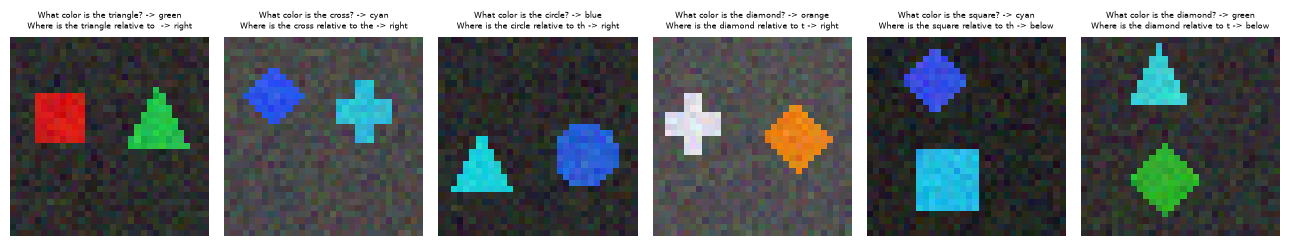

In [5]:
_t0_data = time.time()
VOCABULARY = CaptionVocabulary()
UNIVERSE = build_caption_universe(VOCABULARY)
CAPTION_IDS = UNIVERSE.train_caption_ids  # 020 の画像 encoder の学習データと同じ意味の集合(1,444 個)
SPLIT_SPECS = {
    "train": (TRAIN_COPIES, TRAIN_RENDER_SEED),
    "validation": (VALIDATION_COPIES, VALIDATION_RENDER_SEED),
    "eval": (EVAL_COPIES, EVAL_RENDER_SEED),
}
SCENES, MEANINGS = {}, {}
for _split, (_copies, _seed) in SPLIT_SPECS.items():
    SCENES[_split] = render_scenes(UNIVERSE, repeat_caption_ids(CAPTION_IDS, _copies), _seed)
    MEANINGS[_split] = [UNIVERSE.meanings[i] for i in SCENES[_split].caption_ids]
    assert SCENES[_split].visible_pixels.min() >= 20  # 2 つの図形がどちらも見えている
assert len(set(UNIVERSE.holdout) & {o for m in MEANINGS["train"] for o in (m.first, m.second)}) == 0
for _a, _b in itertools.combinations(SCENES, 2):  # 分割の間で同じ画像がない
    _ha = {sha256_of_tensor(x) for x in SCENES[_a].images}
    assert not _ha & {sha256_of_tensor(x) for x in SCENES[_b].images}, (_a, _b)
NUM_IMAGES = {k: len(v.caption_ids) for k, v in SCENES.items()}

# --- 質問とキャプションの事例 ---
QUESTIONS = {k: build_questions(m) for k, m in MEANINGS.items()}
CAPTION_EXAMPLES = {k: build_caption_examples(m) for k, m in MEANINGS.items()}
for _split, _qs in QUESTIONS.items():
    assert len(_qs) == 4 * NUM_IMAGES[_split]
    for _qtype, _templates in (("color", COLOR_TEMPLATES), ("spatial", SPATIAL_TEMPLATES)):
        _counts = np.bincount([q.template_index for q in _qs if q.question_type == _qtype], minlength=len(_templates))
        assert (_counts == _counts[0]).all(), (_split, _qtype, _counts)  # テンプレートの割合が等しい
        assert {q.answer for q in _qs if q.question_type == _qtype} <= set(ANSWER_VOCABULARY[_qtype])
_train_answers = {(q.question_type, q.answer) for q in QUESTIONS["train"]}
assert {(q.question_type, q.answer) for q in QUESTIONS["eval"]} <= _train_answers  # 評価の答えはすべて学習用に現れる
assert {q.question for q in QUESTIONS["eval"]} <= {q.question for q in QUESTIONS["train"]}  # 評価の質問の文字列も既知
QUESTION_TYPE_OF_EVAL = np.array([q.question_type for q in QUESTIONS["eval"]])
EVAL_IMAGE_OF_QUESTION = np.array([q.image_index for q in QUESTIONS["eval"]])
EVAL_ANSWERS = [q.answer for q in QUESTIONS["eval"]]
PRIOR_UPPER_BOUND = {"all": language_prior_upper_bound(QUESTIONS["eval"])} | {
    t: language_prior_upper_bound([q for q in QUESTIONS["eval"] if q.question_type == t]) for t in QUESTION_TYPES
}

# --- 符号化(視覚トークンの取り方ごとに、全事例の最大長にそろえる) ---
NUM_VISUAL_TOKENS = {"patch": NUM_PATCHES, "mean": 1}
PLACEHOLDER_ID = PAD_ID = 0  # 枠の位置とパディングのトークン ID(出力に影響しないことを 5.5 節で確かめる)
_kinds = {"caption": CAPTION_EXAMPLES, "question": QUESTIONS}
SEQ_LEN, ENCODED = {}, {}
for _pooling, _nv in NUM_VISUAL_TOKENS.items():
    _probe = [
        encode_visual_examples(e[s], tokenizer.encode, tokenizer.decode, _nv, CONTEXT_LENGTH, PLACEHOLDER_ID, PAD_ID)
        for e in _kinds.values() for s in SCENES
    ]
    SEQ_LEN[_pooling] = max(int(d.lengths.max()) for d in _probe)
    for _kind, _examples in _kinds.items():
        for _split in SCENES:
            _d = encode_visual_examples(
                _examples[_split], tokenizer.encode, tokenizer.decode, _nv, SEQ_LEN[_pooling], PLACEHOLDER_ID, PAD_ID
            )
            assert _d.visual_start == len(tokenizer.encode(PROMPT_PREFIX))
            ENCODED[(_pooling, _kind, _split)] = _d.to(device)
VISUAL_START = ENCODED[("patch", "question", "train")].visual_start
_response_lengths = [int((d.lengths - d.prompt_lengths).max()) for (_, k, _), d in ENCODED.items() if k == "question"]
_prompt_lengths = {p: max(int(ENCODED[(p, k, s)].prompt_lengths.max()) for k in _kinds for s in SCENES) for p in NUM_VISUAL_TOKENS}
_text_lengths = {p: (ENCODED[(p, "question", "eval")].lengths - NUM_VISUAL_TOKENS[p]).cpu() for p in NUM_VISUAL_TOKENS}
assert torch.equal(_text_lengths["patch"], _text_lengths["mean"])  # テキストの部分 S_t は視覚トークンの取り方によらない
# 視覚トークン数と文脈長(3.6 節): 全事例の S = S_t + N_v、指示部分 + 生成の上限が文脈長以下
for _pooling in NUM_VISUAL_TOKENS:
    assert SEQ_LEN[_pooling] <= CONTEXT_LENGTH, ("系列長が文脈長を超える", _pooling, SEQ_LEN[_pooling])
    assert _prompt_lengths[_pooling] + MAX_NEW_TOKENS <= CONTEXT_LENGTH, ("生成の長さが文脈長を超える", _pooling)
assert max(_response_lengths) <= MAX_NEW_TOKENS  # 正解の応答部分は生成の上限トークン数に収まる
assert SEQ_LEN["patch"] - SEQ_LEN["mean"] == NUM_PATCHES - 1

# --- パッチ特徴(凍結した画像 encoder、一度だけ計算する) ---
FEATURE_CHUNK = 1024


def compute_patch_features(images_uint8: torch.Tensor) -> torch.Tensor:
    parts = [
        vision_patch_features(VISION, normalize_scene_images(images_uint8[s : s + FEATURE_CHUNK].to(device)), VISION_LAYER)
        for s in range(0, images_uint8.size(0), FEATURE_CHUNK)
    ]
    return torch.cat(parts)


FEATURES = {k: compute_patch_features(v.images) for k, v in SCENES.items()}
for _split, _f in FEATURES.items():
    assert _f.shape == (NUM_IMAGES[_split], NUM_PATCHES, VISION_DIM) and _f.dtype == torch.float32 and not _f.requires_grad
    _again = compute_patch_features(SCENES[_split].images)  # 同じ手順で計算し直す
    assert torch.equal(_f, _again), _split
    del _again
_single = torch.cat([compute_patch_features(SCENES["eval"].images[i : i + 1]) for i in range(8)])
FEATURE_CHUNK_DIFF = float((_single - FEATURES["eval"][:8]).abs().max())  # 一度に計算する枚数を変えたときの差(参考)
PATCH_FEATURE_NORM = float(FEATURES["train"].norm(dim=-1).mean())
MEAN_POOLED_NORM = float(FEATURES["train"].mean(dim=1).norm(dim=-1).mean())

# --- 画像の差し替え(前提条件 P2): どの画像も、自分と異なる意味の画像に移る固定の置換 ---
_rng = np.random.default_rng(SWAP_SEED)
_eval_captions = SCENES["eval"].caption_ids
while True:
    SWAP_PERMUTATION = _rng.permutation(NUM_IMAGES["eval"])
    if (_eval_captions[SWAP_PERMUTATION] != _eval_captions).all():
        break
SWAPPED_EVAL_IMAGE_INDEX = torch.as_tensor(SWAP_PERMUTATION[EVAL_IMAGE_OF_QUESTION], device=device)
DATA_SECONDS = time.time() - _t0_data

print(
    "画像: " + "、".join(f"{k} {NUM_IMAGES[k]:,} 枚(シード {SPLIT_SPECS[k][1]})" for k in SCENES)
    + "。除外した組を含まない、分割の間で同じ画像がない: OK"
)
print(
    "事例: " + "、".join(f"{k} 質問 {len(QUESTIONS[k]):,}・キャプション {len(CAPTION_EXAMPLES[k]):,}" for k in SCENES)
    + "。テンプレートの割合が各分割で等しい、評価の答えと質問の文字列はすべて学習用に現れる: OK"
)
print(f"画像を見ない戦略の正解率の上界(評価集合): {json.dumps({k: round(v, 4) for k, v in PRIOR_UPPER_BOUND.items()})}")
for _qtype in QUESTION_TYPES:
    _ans = [q.answer for q in QUESTIONS["eval"] if q.question_type == _qtype]
    print(f"  {_qtype} の答えの分布(評価集合): {dict(sorted(Counter(_ans).items()))}")
print(
    f"視覚トークンの枠の開始位置 {VISUAL_START}(接頭部分 {PROMPT_PREFIX!r} のトークン数)、テキストの部分 S_t: "
    f"最小 {int(_text_lengths['patch'].min())}・最大 {int(_text_lengths['patch'].max())}"
)
for _pooling, _nv in NUM_VISUAL_TOKENS.items():
    print(
        f"  {_pooling}: N_v = {_nv}、系列長 S の最大 {SEQ_LEN[_pooling]}、指示部分の最大 {_prompt_lengths[_pooling]} + 生成の上限 {MAX_NEW_TOKENS} "
        f"= {_prompt_lengths[_pooling] + MAX_NEW_TOKENS} <= 文脈長 {CONTEXT_LENGTH}: OK"
    )
print(f"質問の応答部分の最大トークン数 {max(_response_lengths)} <= 生成の上限 {MAX_NEW_TOKENS}: OK")
print(
    f"パッチ特徴: 形状 {tuple(FEATURES['train'].shape)}(学習用)、同じ手順で計算し直すと bit 単位で一致: OK、"
    f"一度に計算する枚数を変えたときの差の最大値 {FEATURE_CHUNK_DIFF:.1e}(参考。学習・評価は常に一度だけ計算した特徴を使う)"
)
print(
    f"平均ノルム: パッチトークン {PATCH_FEATURE_NORM:.2f}、平均プール {MEAN_POOLED_NORM:.2f}、言語モデルのトークン埋め込み "
    f"{TOKEN_EMBEDDING_NORM:.4f}(比 {PATCH_FEATURE_NORM / TOKEN_EMBEDDING_NORM:.1f})"
)
print(f"画像の差し替えの置換: 全 {NUM_IMAGES['eval']:,} 枚が自分と異なる意味の画像に移る: OK。データの準備 {DATA_SECONDS:.1f}s")

_fig, _axes = plt.subplots(1, 6, figsize=(13, 2.9))
for _k, _ax in enumerate(_axes):
    _i = _k * (NUM_IMAGES["eval"] // 6) + 1
    _ax.imshow(SCENES["eval"].images[_i].permute(1, 2, 0).numpy())
    _qs = [q for q in QUESTIONS["eval"] if q.image_index == _i]
    _ax.set_title("\n".join(f"{q.question[:34]} -> {q.answer}" for q in _qs[1:4:2]), fontsize=6)
    _ax.axis("off")
plt.tight_layout()
plt.show()

### 5.5 モデルの構築と不変条件の確認

学習の部品(`build_llava()`・`add_lora()`・`train_stage1()`・`train_stage2()`)をここで定義し、次を確かめる。

- **埋め込みの列からの順伝播**: `language_model_hidden_states()`にトークン埋め込み`token_embedding(ids)`を渡して`lm_head`を掛けた
  logits が、既存の`GPTLanguageModel.forward(ids)`と bit 単位で一致すること(LoRA を掛ける前と後)。
- **視覚トークンの差し込み**: 枠の位置のトークン ID を別の値に変えても、隠れ状態が bit 単位で変わらないこと(差し込みで置き換わる)。
  枠の外のトークンを変えると変わること(確認の検出力)。右側のパディングを変えても、応答の位置の logits が変わらないこと(因果マスク)。
- **パッチ特徴の層**: `vision_patch_features(..., L - 1)`が、埋め込みと先頭 $L - 1$ ブロックを手で順に通したもののパッチの位置と一致し、
  その系列([CLS] を含む)に最終ブロックと最終正規化を掛けた [CLS] の表現が、020 の`forward_features()`と一致すること
  (取り出しているのが「最終層の一つ前」であることの確認)。
- **平均プール**: 平均プールの視覚トークンが、パッチトークンの平均に projection 層を掛けたものと一致すること。
- **損失**: `response_loss()`が、全位置の logits から応答部分の対数確率だけを足した FP64 の参照実装と一致し(相対誤差 $10^{-12}$ 以下)、
  016 の`compute_instruction_tuning_loss(..., include_prompt_loss=False)`(内部で FP32 に変換して計算する)とも FP32 の精度
  (相対誤差 $10^{-5}$ 以下)で一致すること(応答の位置だけを語彙に射影する最適化の確認)。
- **LoRA の初期値**: LoRA を掛けた直後の出力が、掛ける前と bit 単位で一致すること($B = 0$)。
- **凍結**: 第 1 段階を数ステップ学習した後、projection 層以外(言語モデル・画像 encoder)のパラメータが bit 単位で変わらないこと。
  第 2 段階では、projection 層と LoRA 以外が変わらないこと。
- **生成**: KV キャッシュを使う`greedy_generate_with_visual_tokens()`の出力が、キャッシュを使わずに毎ステップ全系列を順伝播して
  argmax をとる素朴な生成と一致すること(パッチトークン全体・平均プール、学習途中のモデル)。
- **対応のある初期値**: 同じシードで構築した P・R・L・M の projection 層の初期値、LoRA の初期値が bit 単位で一致すること。

In [6]:
_t0_checks = time.time()


def build_llava(pooling: str, seed: int) -> LlavaStyleModel:
    # projection 層の初期化はシード s の PROJECTION_SEED_BASE + s で決める(条件によらず同じ形状・同じ値)
    torch.manual_seed(PROJECTION_SEED_BASE + seed)
    projection = VisualProjection(VISION_DIM, D_MODEL, PROJECTION_KIND)
    return LlavaStyleModel(build_language_model(), projection, VISUAL_START, pooling).to(device)


def add_lora(model: LlavaStyleModel, seed: int) -> list[str]:
    # 言語モデルの Query・Value 射影に LoRA を掛ける(A の初期化は LORA_SEED_BASE + s)。projection 層は学習可能のまま
    torch.manual_seed(LORA_SEED_BASE + seed)
    return apply_lora(model.language_model, LORA_TARGET_MODULES, rank=LORA_RANK, alpha=LORA_ALPHA)


def trainable_parameters(model: LlavaStyleModel) -> list[nn.Parameter]:
    return [p for p in model.parameters() if p.requires_grad]


def train_steps(model, data, steps, learning_rate, data_seed, evaluation_steps=(), evaluation_fn=None, batch_size=BATCH_SIZE):
    params = trainable_parameters(model)
    optimizer = AdamW(params, lr=learning_rate, weight_decay=WEIGHT_DECAY, foreach=True)
    warmup = warmup_steps_for(steps)

    def schedule(step: int) -> float:
        return compute_warmup_cosine_learning_rate(step, warmup, steps, learning_rate, learning_rate * MIN_LEARNING_RATE_RATIO)

    batches = make_step_batches(len(data), steps, batch_size, data_seed)
    history = train_visual_instruction(
        model, data, FEATURES["train"], batches, optimizer, params, schedule, GRADIENT_CLIP_THRESHOLD, evaluation_steps, evaluation_fn
    )
    history["batch_sha256"] = hashlib.sha256(batches.tobytes()).hexdigest()
    history["steps"] = steps
    history["trainable_names"] = sorted(n for n, p in model.named_parameters() if p.requires_grad)
    return history


def train_stage1(model, seed, learning_rate, steps=STAGE1_STEPS):
    # 第 1 段階: projection 層のみ(言語モデルは凍結)。キャプションの事例
    assert all(not p.requires_grad for p in model.language_model.parameters())
    return train_steps(model, ENCODED[(model.pooling, "caption", "train")], steps, learning_rate, STAGE1_DATA_SEED_BASE + seed)


def validation_nll(model, kind: str) -> float:
    # 検証集合の答え(またはキャプション)のトークンあたりの負の対数尤度(教師強制)
    result = evaluate_response_negative_log_likelihood(
        model, ENCODED[(model.pooling, kind, "validation")], FEATURES["validation"], EVAL_BATCH_SIZE
    )
    return float(result["sum"].sum() / result["count"].sum())


def train_stage2(model, seed, learning_rate, steps, intermediate=True):
    # 第 2 段階: projection 層 + LoRA。質問の事例。途中の評価は検証集合の負の対数尤度(診断量)
    evaluation_steps = intermediate_eval_steps_for(steps) if intermediate else ()
    return train_steps(
        model, ENCODED[(model.pooling, "question", "train")], steps, learning_rate, STAGE2_DATA_SEED_BASE + seed,
        evaluation_steps, lambda m: {"validation_nll": validation_nll(m, "question")},
    )


def visual_token_norm(model) -> float:
    # 検証用の画像の視覚トークンの平均ノルム(診断量)
    with torch.no_grad():
        return float(model.visual_tokens(FEATURES["validation"][:512]).norm(dim=-1).mean())


def parameter_snapshot(module: nn.Module) -> dict[str, torch.Tensor]:
    return {n: p.detach().clone() for n, p in module.named_parameters()}


# --- 埋め込みの列からの順伝播が forward() と bit 単位で一致する(LoRA の前後) ---
_m = build_llava("patch", 0).eval()
_ids = ENCODED[("patch", "question", "validation")].token_ids[:16]
with torch.no_grad():
    _lm = _m.language_model
    assert torch.equal(_lm.lm_head(language_model_hidden_states(_lm, _lm.token_embedding(_ids))), _lm(_ids))
    _before_lora = _m(_ids, FEATURES["validation"][:16])
    add_lora(_m, 0)
    _m.to(device)
    for _name, _module in _m.language_model.named_modules():  # 検証のため LoRA の B を非零にする(確認の検出力)
        if isinstance(_module, LoRALinear):
            _module.lora_b.normal_(std=0.02, generator=torch.Generator(device=device).manual_seed(1))
    assert torch.equal(_lm.lm_head(language_model_hidden_states(_lm, _lm.token_embedding(_ids))), _lm(_ids))
del _m

# --- LoRA の初期値(B = 0)では出力が変わらない ---
_m = build_llava("patch", 0).eval()
with torch.no_grad():
    _f = FEATURES["validation"][:16]
    _out0 = _m(_ids, _f)
    assert torch.equal(_out0, _before_lora)  # 同じシードで構築すれば同じ出力
    _replaced = add_lora(_m, 0)
    _m.to(device)
    assert torch.equal(_m(_ids, _f), _out0)
    assert len(_replaced) == len(LORA_TARGET_MODULES) * NUM_LAYERS
    assert sum(p.numel() for n, p in _m.language_model.named_parameters() if p.requires_grad) == LORA_PARAMETERS

    # --- 視覚トークンの枠の位置のトークン ID は出力に影響しない / 枠の外は影響する / 右側のパディングは影響しない ---
    _slot = slice(VISUAL_START, VISUAL_START + NUM_PATCHES)
    _changed_slot = _ids.clone()
    _changed_slot[:, _slot] = torch.randint(1, 8000, _changed_slot[:, _slot].shape, generator=torch.Generator().manual_seed(2)).to(device)
    _h0 = _m.hidden_states(_ids, _f)
    assert torch.equal(_m.hidden_states(_changed_slot, _f), _h0)
    _changed_text = _ids.clone()
    _changed_text[:, VISUAL_START + NUM_PATCHES + 1] += 1
    assert (_m.hidden_states(_changed_text, _f) - _h0).abs().max() > 1e-4
    _d = ENCODED[("patch", "question", "validation")]
    _changed_pad = _ids.clone()
    _pad_positions = torch.arange(_ids.size(1), device=device)[None, :] >= _d.lengths[:16, None]
    _changed_pad[_pad_positions] = 777
    _mask = _d.response_target_mask[:16]
    assert torch.equal(_m.response_logits(_changed_pad, _f, _mask)[0], _m.response_logits(_ids, _f, _mask)[0])

# --- パッチ特徴は「最終層の一つ前」の層: 手で通したものと一致し、最終ブロックと最終正規化で forward_features() に戻る ---
with torch.no_grad():
    _x = normalize_scene_images(SCENES["eval"].images[:8].to(device))
    _hidden = VISION.embed(_x)
    for _block in VISION.blocks[:VISION_LAYER]:
        _hidden, _ = _block(_hidden)
    assert torch.equal(_hidden[:, 1:], vision_patch_features(VISION, _x, VISION_LAYER))
    _last, _ = VISION.blocks[VISION_LAYER](_hidden)
    assert VISION_LAYER == VISION_NUM_LAYERS - 1
    assert torch.equal(VISION.final_norm(_last)[:, 0], VISION.forward_features(_x))

# --- 平均プール ---
_mm = build_llava("mean", 0)
with torch.no_grad():
    _vt = _mm.visual_tokens(_f)
    assert _vt.shape == (16, 1, D_MODEL)
    assert torch.equal(_vt, _mm.projection(_f.mean(dim=1, keepdim=True)))
del _mm

# --- 損失: 応答の位置だけを射影した損失が、016 の損失マスクありの損失と FP64 で一致する ---
_cpu_model = copy.deepcopy(_m).to("cpu").double()
_ids_cpu, _f_cpu, _mask_cpu = _ids.cpu(), _f.cpu().double(), _mask.cpu()
# 016 の collate_instruction_batch() と同じ定義の指示部分のマスク(損失マスクありでは損失に使われない)
_prompt_mask = torch.arange(_ids.size(1) - 1)[None, :] < (_d.prompt_lengths[:16, None].cpu() - 1)
with torch.no_grad():
    _full = _cpu_model(_ids_cpu, _f_cpu)  # 全位置の logits(FP64)
    _ours = response_loss(_cpu_model, _ids_cpu, _f_cpu, _mask_cpu)
    # FP64 の参照実装: 全位置の対数確率から、応答部分の予測対象の位置だけを足す
    _log_probs = torch.log_softmax(_full[:, :-1], dim=-1).gather(-1, _ids_cpu[:, 1:, None])[..., 0]
    _manual = -(_log_probs * _mask_cpu).sum() / _mask_cpu.sum()
    # 016 の損失マスクありの損失(内部で FP32 に変換して計算する)
    _reference = compute_instruction_tuning_loss(_full, _ids_cpu, _prompt_mask, _mask_cpu, include_prompt_loss=False)
assert _ours["loss"].dtype == torch.float64 and math.isclose(float(_ours["loss"]), float(_manual), rel_tol=1e-12)
assert math.isclose(float(_ours["loss"]), float(_reference["loss"]), rel_tol=1e-5)
assert int(_ours["count"]) == int(_reference["response_count"])
LOSS_CHECK_DIFF = abs(float(_ours["loss"]) - float(_reference["loss"]))
del _cpu_model

# --- 凍結: 第 1 段階では projection 層だけ、第 2 段階では projection 層と LoRA だけが変わる ---
_frozen_check = {}
for _stage in (1, 2):
    _mc = build_llava("patch", 0)
    if _stage == 2:
        add_lora(_mc, 0)
        _mc.to(device)
    _before = parameter_snapshot(_mc)
    _vision_before = parameter_snapshot(VISION)
    _data = ENCODED[("patch", "caption" if _stage == 1 else "question", "train")]
    _h = train_steps(_mc, _data, 3, 1e-3, 0)
    _changed = {n for n, p in _mc.named_parameters() if not torch.equal(p.detach(), _before[n])}
    _expected = {n for n in _before if n.startswith("projection.") or (_stage == 2 and ".lora_" in n)}
    assert _changed == _expected, (_stage, sorted(_changed ^ _expected)[:5])
    assert all(torch.equal(p, _vision_before[n]) for n, p in VISION.named_parameters())
    assert all(math.isfinite(x) for x in _h["loss"])
    _frozen_check[_stage] = len(_changed)
    del _mc

# --- 生成: KV キャッシュの生成と、キャッシュなしの素朴な生成が一致する(学習途中のモデル) ---


def naive_greedy(model, prompt_ids: list[int], features_one: torch.Tensor, max_new: int) -> list[int]:
    out = []
    ids = torch.tensor([prompt_ids], device=device)
    for _ in range(max_new):
        with torch.no_grad():
            nxt = int(model(ids, features_one[None])[0, -1].argmax())
        out.append(nxt)
        if END_MARKER in tokenizer.decode(out):
            break
        ids = torch.cat([ids, torch.tensor([[nxt]], device=device)], dim=1)
    return out


_generation_check = {}
for _pooling in ("patch", "mean"):
    _mg = build_llava(_pooling, 0)
    add_lora(_mg, 0)
    _mg.to(device)
    train_steps(_mg, ENCODED[(_pooling, "question", "train")], 40, 3e-3, 0)  # 出力が自明でない状態にする
    _dv = ENCODED[(_pooling, "question", "validation")]
    _sel = torch.arange(0, 64, device=device) * 37
    _prompts = [row[:n] for row, n in zip(_dv.token_ids[_sel].tolist(), _dv.prompt_lengths[_sel].tolist(), strict=True)]
    _feat = FEATURES["validation"][_dv.image_indices[_sel]]
    _cached = greedy_generate_with_visual_tokens(_mg, _prompts, _feat, tokenizer.decode, END_MARKER, MAX_NEW_TOKENS, batch_size=16)
    _naive = [naive_greedy(_mg, p, _feat[i], MAX_NEW_TOKENS) for i, p in enumerate(_prompts)]
    assert _cached == _naive, _pooling
    _generation_check[_pooling] = len(_prompts)
    del _mg

# --- 対応のある初期値: 同じシードの P・R・L・M の projection 層と LoRA の初期値が一致する ---
_init = {}
for _cond, _spec in CONDITIONS.items():
    _mi = build_llava(_spec["pooling"], 3)
    add_lora(_mi, 3)
    _init[_cond] = {n: p.detach().cpu() for n, p in _mi.named_parameters() if p.requires_grad}
    del _mi
for _cond in CONDITIONS:
    assert _init[_cond].keys() == _init["P"].keys() and all(torch.equal(_init[_cond][k], _init["P"][k]) for k in _init["P"])
# L の第 2 段階のミニバッチの先頭 T_2 ステップは、R と同じ(同じシード・同じ規則)
_n_q = len(ENCODED[("patch", "question", "train")])
assert np.array_equal(
    make_step_batches(_n_q, STAGE1_STEPS + STAGE2_STEPS, BATCH_SIZE, 7)[:STAGE2_STEPS], make_step_batches(_n_q, STAGE2_STEPS, BATCH_SIZE, 7)
)
del _m, _init
empty_device_cache()
CHECK_SECONDS = time.time() - _t0_checks
print("埋め込みの列からの順伝播が GPTLanguageModel.forward() と bit 単位で一致(LoRA の前後): OK")
print(f"LoRA を掛けた直後の出力が掛ける前と bit 単位で一致、LoRA の学習可能パラメータ数 {LORA_PARAMETERS:,}: OK")
print("枠の位置のトークン ID は隠れ状態に影響しない・枠の外は影響する・右側のパディングは応答の logits に影響しない: OK")
print(f"パッチ特徴は {VISION_LAYER} ブロックの後(最終層の一つ前)で、最終ブロックと最終正規化で forward_features() に戻る: OK")
print("平均プールの視覚トークン = projection(パッチトークンの平均): OK")
print(f"応答の位置だけを射影した損失が FP64 の参照実装と一致(相対 1e-12)、016 の損失マスクありの損失(FP32 で計算)との差 {LOSS_CHECK_DIFF:.1e}: OK")
print(f"凍結: 第 1 段階で変わったのは projection 層のみ({_frozen_check[1]} テンソル)、第 2 段階は projection 層と LoRA のみ({_frozen_check[2]} テンソル)、画像 encoder は不変: OK")
print(f"KV キャッシュの生成とキャッシュなしの素朴な生成が一致: {_generation_check} 事例: OK")
print("同じシードの P・R・L・M の projection 層と LoRA の初期値が bit 単位で一致、L のミニバッチの先頭 T_2 ステップは R と同じ: OK")
print(f"確認の実行時間 {CHECK_SECONDS:.1f}s")

埋め込みの列からの順伝播が GPTLanguageModel.forward() と bit 単位で一致(LoRA の前後): OK
LoRA を掛けた直後の出力が掛ける前と bit 単位で一致、LoRA の学習可能パラメータ数 32,768: OK
枠の位置のトークン ID は隠れ状態に影響しない・枠の外は影響する・右側のパディングは応答の logits に影響しない: OK
パッチ特徴は 3 ブロックの後(最終層の一つ前)で、最終ブロックと最終正規化で forward_features() に戻る: OK
平均プールの視覚トークン = projection(パッチトークンの平均): OK
応答の位置だけを射影した損失が FP64 の参照実装と一致(相対 1e-12)、016 の損失マスクありの損失(FP32 で計算)との差 6.8e-07: OK
凍結: 第 1 段階で変わったのは projection 層のみ(2 テンソル)、第 2 段階は projection 層と LoRA のみ(18 テンソル)、画像 encoder は不変: OK
KV キャッシュの生成とキャッシュなしの素朴な生成が一致: {'patch': 64, 'mean': 64} 事例: OK
同じシードの P・R・L・M の projection 層と LoRA の初期値が bit 単位で一致、L のミニバッチの先頭 T_2 ステップは R と同じ: OK
確認の実行時間 13.1s


### 5.6 学習と評価のヘルパー

- **1 つの学習**: `(条件, シード)`の組で表す。`run_condition()`は、projection 層の構築 → (第 1 段階)→ LoRA を掛ける → 第 2 段階 →
  評価、を行い、記録を返す。第 1 段階の前後と第 2 段階の開始時・途中(25%・50%・75%)・終わりに検証集合の負の対数尤度を、
  第 1 段階の前後と第 2 段階の後に視覚トークンの平均ノルムを記録する(前提条件 P1 と診断量)。
- **評価**(`purpose="main"`のときのみ、学習の最終ステップの重み): 評価集合の全 5,776 事例を生成で採点し、事例ごとの正誤を記録する。
  続いて、画像を差し替えた評価(前提条件 P2)を行う。
- **較正の学習**(`purpose="calibration"`)は、評価集合を一切評価しない(記録に評価集合の鍵を持たないことを 6.10 節で確かめる)。

In [7]:
def evaluate_generation(model, image_indices=None) -> np.ndarray:
    # 評価集合の各事例を貪欲法で生成して採点し、正誤(bool の配列、QUESTIONS["eval"] の順)を返す
    data = ENCODED[(model.pooling, "question", "eval")]
    texts = generate_answers(model, data, FEATURES["eval"], tokenizer.decode, MAX_NEW_TOKENS, image_indices, EVAL_BATCH_SIZE)
    return np.array([score_generated_response(t, a.split())[1] for t, a in zip(texts, EVAL_ANSWERS, strict=True)])


def accuracy_by_type(correct: np.ndarray) -> dict:
    return {"all": float(correct.mean())} | {t: float(correct[QUESTION_TYPE_OF_EVAL == t].mean()) for t in QUESTION_TYPES}


def run_condition(condition: str, seed: int, lr1: float | None, lr2: float, purpose: str, stage1_projection: dict | None = None) -> dict:
    # 1 つの学習(条件・シード)。stage1_projection を与えると、第 1 段階を行わずにその projection 層から第 2 段階を始める(較正用)
    assert purpose in ("calibration", "main")
    spec = CONDITIONS[condition]
    t0 = time.time()
    model = build_llava(spec["pooling"], seed)
    record = {"condition": condition, "seed": seed, "purpose": purpose, "lr1": lr1, "lr2": lr2, "pooling": spec["pooling"]}
    record["initial_trainable_sha256"] = hashlib.sha256(
        b"".join(p.detach().cpu().numpy().tobytes() for p in model.projection.parameters())
    ).hexdigest()
    record["norm_init"] = visual_token_norm(model)
    if spec["stage1"] and stage1_projection is None:
        record["stage1_nll_before"] = validation_nll(model, "caption")
        record["stage1_history"] = train_stage1(model, seed, lr1)
        record["stage1_nll_after"] = validation_nll(model, "caption")
        record["norm_after_stage1"] = visual_token_norm(model)
    elif stage1_projection is not None:
        model.projection.load_state_dict(stage1_projection)
    add_lora(model, seed)
    model.to(device)
    record["lora_init_sha256"] = hashlib.sha256(
        b"".join(p.detach().cpu().numpy().tobytes() for n, p in model.named_parameters() if ".lora_" in n)
    ).hexdigest()
    record["stage2_nll_start"] = validation_nll(model, "question")
    record["stage2_history"] = train_stage2(model, seed, lr2, spec["stage2_steps"])
    record["stage2_nll_end"] = validation_nll(model, "question")
    record["norm_after_stage2"] = visual_token_norm(model)
    if purpose == "main":  # 評価集合は本番の学習でのみ評価する(較正では評価しない)
        record["correct"] = evaluate_generation(model)
        record["correct_swapped"] = evaluate_generation(model, SWAPPED_EVAL_IMAGE_INDEX)
        record["accuracy"] = accuracy_by_type(record["correct"])
        record["accuracy_swapped"] = accuracy_by_type(record["correct_swapped"])
    record["seconds"] = time.time() - t0
    record["projection_state"] = {k: v.detach().cpu().clone() for k, v in model.projection.state_dict().items()}
    del model
    empty_device_cache()
    return record


def describe(record: dict) -> str:
    text = f"{record['condition']} s={record['seed']} lr1={record['lr1']} lr2={record['lr2']:.3g}:"
    if "stage1_nll_after" in record:
        text += f" 第 1 段階の検証 NLL {record['stage1_nll_before']:.3f} -> {record['stage1_nll_after']:.3f}、"
    text += f" 第 2 段階の検証 NLL {record['stage2_nll_start']:.3f} -> {record['stage2_nll_end']:.4f}"
    if "accuracy" in record:
        a, b = record["accuracy"], record["accuracy_swapped"]
        text += f"、正解率 {a['all']:.4f}(色 {a['color']:.4f}・位置関係 {a['spatial']:.4f})、差し替え {b['all']:.4f}"
    return text + f"、{record['seconds']:.0f}s"


def judge(value: float, sigma: float) -> str:
    # 支持 / 反証 / 判定不能(前提不成立は 6.11 節で前提条件から決める)
    if value > SIGMA_MULTIPLIER * sigma:
        return "支持"
    if value < -SIGMA_MULTIPLIER * sigma:
        return "反証"
    return "判定不能"


_tag = "[動作確認のみ、結論ではない] " if SMOKE_TEST else ""
_plot_tag = "[smoke test, not a result] " if SMOKE_TEST else ""  # 図のタイトル用(英字のみ)

### 5.7 線形プローブ(実験 B の診断量)

凍結した画像 encoder の最終層の一つ前の層の特徴から、次の 2 つの量を多クラスのロジスティック回帰(線形プローブ、Alain & Bengio [8])で
当てる。言語モデル・projection 層とは独立で、学習の条件にもシードにもよらない。

| 標的 | クラス | 必要な情報 |
|---|---|---|
| 配置(`layout`) | 位置関係の種類(左右 / 上下)× 左(または上)の図形の形 = $2 \times 5 = 10$ | どの形がどちらの側にあるか(位置と形の結びつき) |
| 形の組(`shape_pair`) | 2 つの図形の形の組(順序なし)= $\binom{5}{2} = 10$ | 位置によらない内容 |

入力は、パッチトークンの格子全体を平坦化したもの($64 \times 128 = 8{,}192$ 次元)と平均プール(128 次元)の 2 通り。学習用の画像の特徴を
学習用の平均と標準偏差で標準化し、重みとバイアスを 0 で初期化して、全バッチの AdamW(学習率 $10^{-2}$、重み減衰 $10^{-4}$)で
500 ステップ学習する。評価用の画像で正解率を測る。2 つの入力の次元が違うので、プローブの容量も違う(格子全体のほうが大きい)。
「平均プールでは配置が当たらないが形の組は当たる」なら、平均プールで失われるのが位置の情報であることを示唆する。

In [8]:
PROBE_TARGETS = ("layout", "shape_pair")
PROBE_INPUTS = ("patch", "mean")
_shape_pairs = list(itertools.combinations(range(len(SHAPES)), 2))


def probe_labels(split: str, target: str) -> torch.Tensor:
    if target == "layout":  # 位置関係の種類 x 左(上)の図形の形
        labels = [m.relation * len(SHAPES) + m.first[1] for m in MEANINGS[split]]
    else:  # 形の組(順序なし)
        labels = [_shape_pairs.index(tuple(sorted((m.first[1], m.second[1])))) for m in MEANINGS[split]]
    return torch.tensor(labels, device=device)


def probe_inputs(split: str, inputs: str) -> torch.Tensor:
    return FEATURES[split].flatten(1) if inputs == "patch" else FEATURES[split].mean(dim=1)


def run_probe(target: str, inputs: str, steps: int = PROBE_STEPS) -> dict:
    x_train, x_eval = probe_inputs("train", inputs), probe_inputs("eval", inputs)
    mean, std = x_train.mean(dim=0), x_train.std(dim=0).clamp_min(1e-6)
    x_train, x_eval = (x_train - mean) / std, (x_eval - mean) / std
    y_train, y_eval = probe_labels("train", target), probe_labels("eval", target)
    num_classes = int(y_train.max()) + 1
    weight = torch.zeros(x_train.size(1), num_classes, device=device, requires_grad=True)
    bias = torch.zeros(num_classes, device=device, requires_grad=True)
    optimizer = AdamW([weight, bias], lr=PROBE_LEARNING_RATE, weight_decay=PROBE_WEIGHT_DECAY, foreach=True)
    for _ in range(steps):
        loss = functional.cross_entropy(x_train @ weight + bias, y_train)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
    with torch.no_grad():
        train_accuracy = float(((x_train @ weight + bias).argmax(dim=1) == y_train).float().mean())
        eval_accuracy = float(((x_eval @ weight + bias).argmax(dim=1) == y_eval).float().mean())
        majority = float(torch.bincount(y_eval).max()) / len(y_eval)
    return {"train": train_accuracy, "eval": eval_accuracy, "classes": num_classes, "majority": majority, "final_loss": float(loss.detach())}


# ラベルの確認: 配置と形の組がそれぞれ 10 クラスで、評価用の全クラスが学習用に現れる
for _target in PROBE_TARGETS:
    _ytr, _yev = probe_labels("train", _target), probe_labels("eval", _target)
    assert int(_ytr.max()) + 1 == 10 and set(_yev.tolist()) <= set(_ytr.tolist())
print(f"線形プローブ: 標的 {PROBE_TARGETS}(各 10 クラス)、入力 {PROBE_INPUTS}(次元 {NUM_PATCHES * VISION_DIM:,} / {VISION_DIM})")

線形プローブ: 標的 ('layout', 'shape_pair')(各 10 クラス)、入力 ('patch', 'mean')(次元 8,192 / 128)


## 6. 実験 / Experiments

### 6.1 実験宣言セル: 共通の設定・検証すること・判定基準・前提条件

**この節の内容は本番実行の前に確定させ、結果を見た後に変更しない。** パイロット(6.2 節)を受けて決めた設定は、本番実行の前に
決めたものであり、6.2 節に経緯を記録した。

#### 共通の設定

- **画像 encoder**: 020 の CLIP の画像 encoder(NegCLIP・シード 0、`kojikojiprg/ai-theories-clip-synthetic-scenes`の`main`)。凍結する。
  最終層の一つ前の層(3 ブロックを通した後、最終正規化の前)のパッチトークン $N = 64$ 個(各 $d_v = 128$ 次元)を使う(3.4 節)。
- **言語モデル**: 008 の小型 GPT(`kojikojiprg/ai-theories-small-gpt-en`の`main`、4 層、$d = 256$、文脈長 256)とトークナイザ。
- **projection 層**: 線形写像 $128 \to 256$(`nn.Linear`の既定の初期化)。
- **第 1 段階**: projection 層のみを学習する。データは学習用の画像とキャプション(5.4 節)。ステップ数 $T_1 = 722$(キャプションのデータの
  2 エポック)。学習率は $6.4 \times 10^{-2}$ に **固定** し、較正しない(6.2 節のパイロットの経緯による。下の「学習率の較正」)。
- **第 2 段階**: projection 層と、言語モデルの Query・Value 射影への LoRA($r = 8$、$\alpha = 8$)を学習する。データは学習用の画像の
  質問と答え(色・位置関係)。ステップ数 $T_2 = 1{,}444$(質問のデータの 1 エポック)。学習率は条件ごとに較正する。
- **学習の部品**: AdamW(重み減衰 0、012・016 と同じ)、バッチ 32 事例、最初の 10% のステップで線形 warmup の後 cosine で最大値の
  0.01 倍まで減衰、gradient clipping の閾値 1.0(学習するパラメータのグローバルノルム)、FP32。損失は答えのトークンだけの負の
  対数尤度の平均(3.5 節)。
- **シード**: シード $s$ が決めるのは、projection 層の初期化(`torch.manual_seed(21100 + s)`)、LoRA の $A$ の初期化
  (`torch.manual_seed(21300 + s)`)、第 1 段階のミニバッチの順序(`make_step_batches(..., 21200 + s)`)、第 2 段階のミニバッチの順序
  (`make_step_batches(..., 21400 + s)`)である。同じシードの条件どうしはこれらを共有する(対応のある比較。6.10 節で確かめる)。
  シードは $0, 1, \dots$ を使い、数は削る段階で決まる。
- **評価集合**: 学習用・検証用と別の乱数シードで描いた評価用の画像 1,444 枚(学習用のキャプション 1,444 個 × 各 1 枚)の質問 5,776 個
  (色 2,888 個・位置関係 2,888 個)。テンプレートと答えの語彙は学習用と同じで、画像だけが学習で見ていないものである(5.4 節)。
- **正解率**: 指示部分(視覚トークンを含む)から貪欲法で生成し(上限 12 トークン)、終端記号`### End`の前の単語の列が正解と
  完全一致した割合(016 の`score_generated_response()`の完全一致)。2 択の評価は使わない。学習の最終ステップの重みで評価する。
  $\mathrm{acc}_{c,s}$ は条件 $c$・シード $s$ の評価集合全体の正解率、$\mathrm{acc}^{\mathrm{color}}_{c,s}$・$\mathrm{acc}^{\mathrm{spatial}}_{c,s}$ は
  色・位置関係の質問だけの正解率である。
- **検証集合**: 評価集合と別の乱数シードで描いた画像 1,444 枚の質問(第 2 段階)とキャプション(第 1 段階)。学習率の較正と前提条件 P1 に
  のみ使う。**評価集合は較正に使わない。**

#### 条件の対応表

| 記号 | 視覚トークン | 第 1 段階 | 第 2 段階のステップ数 | 使う実験 |
|---|---|---|---|---|
| P | パッチトークン全体($N_v = 64$) | あり($T_1$) | $T_2$ | 実験 A の条件 1・実験 B の条件 1 |
| R | パッチトークン全体($N_v = 64$) | なし(projection 層は乱数の初期値) | $T_2$ | 実験 A の条件 2 |
| L | パッチトークン全体($N_v = 64$) | なし(projection 層は乱数の初期値) | $T_1 + T_2$ | 実験 A の診断量(判定なし) |
| M | 平均プール($N_v = 1$) | あり($T_1$) | $T_2$ | 実験 B の条件 2 |

数式の添字の $c \in \{P, R, L, M\}$ はこの表の記号である。

#### 学習率の較正(本番の冒頭、6.5 節)

- **第 1 段階の学習率は較正しない**($6.4 \times 10^{-2}$ に固定、全条件・全シードで共通)。6.2 節のパイロットで、第 1 段階の検証集合の
  キャプションの負の対数尤度は、学習率を $8 \times 10^{-3}$ から $2.56 \times 10^{-1}$ まで 32 倍変えても条件内の相対差が 5% 以内
  (平均プールでは 0.3% 以内)で、格子の上端に向かって単調にわずかに下がり続けた。この指標では内点の最良値が定まらず、較正しても
  前提条件 P0 が学習率の選択と無関係な理由で不成立になる。原論文も第 1 段階の学習率は固定の値($2 \times 10^{-3}$)である。
  規則で決めた値なので、第 1 段階の学習率は較正に関する前提条件(P0)の対象外である。P と M に同じ値を使うので、この値が最適から
  ずれたときの対比量への偏りは、実験 A では P のみが第 1 段階を持つので **負の向き**(第 1 段階の効果を過小に見る側)、実験 B では
  P・M の両方に効き、向きは事前には定まらない。
- **第 2 段階の格子**: 条件 $c$ の中心 $\eta_{2,c}$(P・R・M とも $8 \times 10^{-3}$、6.2 節のパイロットで決めた)の $\{1/2, 1, 2\}$ 倍
  (公比 2 の 3 点)。
- **指標**: 本番と同じステップ数・全学習データで、**較正専用のシード**(シード番号 90。実験のシードと共有しない)の 1 シードで
  各格子点を学習し、**検証集合の答えのトークンあたりの負の対数尤度**(教師強制)が最小の学習率を選ぶ(同点なら小さい方)。
  生成の正解率は較正に使わない。
- **拡張の規則**: 最良の学習率が格子の端に来た場合は、その方向に公比 2 で 1 点だけ格子を拡張して学習し、改めて最良を選ぶ(1 回のみ)。
- **較正の起点**: P・M の第 2 段階の較正は、較正のシードで固定の学習率の第 1 段階を学習した projection 層から始める(視覚トークンの
  取り方ごとに 1 回)。R は乱数の初期値の projection 層から始める。
- **較正の方式**`CALIBRATION_MODE`(選ばれた実行計画から決まる、下の「実行計画」):
  - `"all"`: 第 2 段階の P・R・M の 3 つをそれぞれ較正する。L は R の値を使う(規則で決める。L は診断量で判定しないので、較正に
    関する前提条件の対象にしない)。
  - `"representative"`: 第 2 段階の P だけを較正し、R・L・M には P の値を使う(規則で決める)。

#### 共通の前提条件

- **P0(較正)**: 較正した各条件で、選んだ学習率が格子の **内点** であること(拡張後も最良が端なら不成立)。各実験が対象とするのは、
  その実験の条件の第 2 段階の学習率を決めた較正である(実験 A: P・R、実験 B: P・M)。第 1 段階の学習率は固定なので対象外。
  `"representative"`で規則で決めた条件の学習率は較正していないので、その条件の P0 は **対象外** になる(下の各実験の「規則で決めた
  学習率による偏り」を参照)。
- **P1(学習の成立)**: その実験の全条件・全シードの学習で、(a)損失がすべてのステップで有限であり、(b)第 2 段階の後の検証集合の
  答えの負の対数尤度(トークンあたり)が、第 2 段階の開始時(第 1 段階の後、または乱数の初期値の projection 層)の値の 0.5 倍以下で
  あること。第 1 段階を行う条件では、加えて(c)第 1 段階の損失がすべてのステップで有限であり、第 1 段階の後の検証集合の
  キャプションの負の対数尤度が、第 1 段階の開始時の値より **小さい** こと。検証したい仮説(条件間の正解率の差)とは独立な、
  「学習が進んだか」の量である。(b)の 0.5 倍は、学習が初期値から明らかに進んだことを表す下限として置いた(パイロットの値から
  決めたものではない)。答えの負の対数尤度は、画像の情報がなくても、形式のトークン(` ### End`など)と答えの語彙の学習だけで大きく
  下がるので、(b)は視覚トークンが運ぶ情報の量によらず満たしうる。(c)を下がり幅ではなく「下がったか」で定義する理由は 6.2 節の
  「スモークテストの後の改訂」に記した。
- **P2(視覚への依存)**: その実験の各条件で、評価集合の各事例の画像を **別の画像に差し替えた** ときの正解率のシード平均が
  **0.5 以下** であること(上限 1 から 0.5 以上離れていること)。差し替えは、評価用の画像の固定の置換(乱数シード 21004、どの画像も
  自分と異なる意味の画像に移る)で行い、全条件・全シードで同じ置換を使う。画像を見ずに質問の文字列だけから答える戦略の正解率の
  上界は、評価集合で約 0.2 である(5.4 節で厳密に計算する)。差し替えた画像での正解率がこの上界を大きく超えて 0.5 を上回るなら、
  モデルは画像以外の手がかり(質問の文字列と答えの偏り)で答えていることになり、正解率の差を視覚の情報の差として解釈できない。
- **P3(改善の余地)**: 基準となる条件の値が上限 1 から十分に離れていること。**差ではなく基準の条件の値で定義する。**
  - 実験 A: R の評価集合の正解率のシード平均 $\overline{\mathrm{acc}}_{R} \le 0.95$。
  - 実験 B: M の位置関係の質問の正解率のシード平均 $\overline{\mathrm{acc}}^{\mathrm{spatial}}_{M} \le 0.95$。
  - **閾値の根拠**: 評価集合の 1 つの質問の種類は 2,888 事例であり、正解率 0.95 の二項分布の標準偏差は
    $\sqrt{0.95 \cdot 0.05 / 2888} \approx 0.004$ である。2 条件の差の標準偏差はその約 $\sqrt{2}$ 倍、判定の閾値はその 2 倍の約 0.012 に
    シード間のばらつきが加わる。上限までの余地 0.05 は、この閾値の 4 倍程度であり、仮説どおりの改善があれば判定の閾値を超えうる
    大きさである。余地がこれより小さいと、仮説が正しくても差が判定の閾値に埋もれうる(020 の実験 B・C の天井効果)。

前提条件が 1 つでも成立しない実験は、判定関数の結果によらず **前提不成立** と記録する(判定不能とは区別する)。

#### 判定の形と標準偏差の単位

各実験の対比量 $\Delta$ とその標準偏差 $\sigma$ に対し、$\Delta > 2\sigma$ なら **支持**、$\Delta < -2\sigma$ なら **反証**、それ以外は
**判定不能** とする。$\sigma$ は、**シード間の分散** と、評価の単位を復元抽出する **対応付きのブートストラップの分散** の和の平方根とする
(013・018 と同じ形)。

$$
\sigma^2 = \frac{s_d^2}{S} + \mathrm{Var}_{\mathrm{boot}}(\Delta^{*})
$$

- $d_s$ はシード $s$ の対比量、$s_d^2$ はその標本分散(自由度 $S - 1$)、$S$ はシード数。第 1 項は、学習の乱数(初期化・ミニバッチの
  順序)によるばらつきの、シード平均の分散の推定である。
- 第 2 項は、評価集合の抽出によるばらつきである。評価の単位は **画像**(1 枚の画像の 4 つの質問は同じ画像を共有して相関するので、
  画像をクラスタとして復元抽出する。015 の`paired_cluster_bootstrap_ratio_of_sums()`)。全条件・全シードに **同じ再標本** を使い
  (対応付き)、再標本ごとにシード平均の対比量 $\Delta^{*}$ を計算して、その分散をとる。反復は本番 10,000 回(スモークテスト 1,000 回)。
- 2 つの項は、それぞれ別の乱数の源(学習 / 評価集合)によるばらつきであり、独立とみなして分散を足す。シード間の分散の推定にも
  評価集合の抽出のばらつきが一部含まれるので、和はやや保守的(大きめ)な推定になる。

#### 実行計画(削る段階と較正の方式の組)と、その自動選択

**削る段階**:

| 段階 | 内容 | 実験 A のシード数 $S_A$(R) | 実験 B のシード数 $S_B$(M) | P のシード数 | L(診断量) |
|---|---|---|---|---|---|
| 0 | 全実験 5 シード | 5 | 5 | 5 | 5 シード |
| 1 | L を除く | 5 | 5 | 5 | なし |
| 2 | 段階 1 に加え、実験 A のシード数を 3 にする | 3 | 5 | 5 | なし |
| 3 | 段階 2 に加え、実験 B のシード数を 3 にする | 3 | 3 | 3 | なし |

P は実験 A・B で共有するので、そのシード数は $\max(S_A, S_B)$ である。各実験の判定には、その実験のシード数の分の P を使う
(シードは先頭から)。

**実行計画**: 次の 8 通りに、優先順位の高い順に番号を付ける。計画 0〜3 は較正の方式`"all"`で段階 0〜3、計画 4〜7 は **下位の計画** で、
較正の方式`"representative"`で段階 0〜3 である。

| 計画 | 0 | 1 | 2 | 3 | 4 | 5 | 6 | 7 |
|---|---|---|---|---|---|---|---|---|
| 段階 | 0 | 1 | 2 | 3 | 0 | 1 | 2 | 3 |
| 較正の方式 | all | all | all | all | representative | representative | representative | representative |

- **選択の規則**: 本番の学習を始める前に(6.4 節)、スケーリングの計測(6.3 節)から、各計画の残りの実行時間(較正・本番の学習と評価・
  診断量・判定)を見積もり、それまでの経過時間を足して予算(T4 で 120 分)以内に収まる計画のうち **番号の最も小さい** ものを選ぶ。
  計画 7 でも超える場合は、学習の前に例外で停止する。**選択は見積もりのみに基づき、どの実験の結果も参照しない。**
- **見積もりの方法**: 学習は、定常状態の 1 ステップの時間(ウォームアップの後に 3 点のステップ数で計測し、ステップ数の差から求めた
  傾き)にステップ数を掛ける。べき乗則のあてはめ($\log t = \log a + b \log n$)も行い、べき指数 $b$ と、比例の値との差を印字する。
  評価(生成・教師強制)は、事例数を 3 点で変えて計測し、べき乗則で外挿する。
- **段階の順序の理由**: まず判定に使わない診断量(L)を除く。次に、対比量が差であり誤差の小さい実験 A のシード数を削る。実験 B は
  差の差を対比量とし、誤差伝播により標準偏差が大きくなりやすいので、シード数を最後に削る。
- **較正の方式を最後に変える理由**: 較正の範囲を削ると、規則で決めた学習率が最適からずれたときに対比量に偏りが生じうる
  (各実験の「規則で決めた学習率による偏り」)。シード数を削ることは精度を下げるだけで偏りを生じないので、先に行う。
- **学習量を下げる段階は設けない**: $T_2$ は、6.2 節のパイロットで、基準の条件の正解率が $T_2$ で上限に届かないこと(真偽のみ)を
  確かめた値である。ステップ数を下げると学習の飽和の程度が変わり、パイロットで確かめた状態から離れるので、削る対象にしない。

#### 実験 A: 第 1 段階(特徴の整列)の効果

**検証すること**: 第 2 段階の前に第 1 段階(projection 層のみの学習)を行うと、第 2 段階のステップ数を揃えたとき、評価集合の
正解率が上がる(Liu et al. [1] のアブレーションで、第 1 段階を省くと正解率が下がったことに対応する)。

**条件**: P(第 1 段階 → 第 2 段階)と R(第 2 段階のみ。projection 層は乱数の初期値)。第 2 段階のステップ数・データ・ミニバッチの順序・
LoRA と projection 層の初期値は同じシードで揃う。

**対比量**: $d_s = \mathrm{acc}_{P,s} - \mathrm{acc}_{R,s}$、$\Delta_A = \frac{1}{S_A} \sum_{s} d_s$($s = 0, \dots, S_A - 1$)。
**仮説の向き**: $\Delta_A > 0$。$\sigma_A$ は上の「判定の形と標準偏差の単位」のとおり(評価の単位は画像、評価集合の全 5,776 事例)。

**判定**: $\Delta_A > 2\sigma_A$ なら支持、$\Delta_A < -2\sigma_A$ なら反証、それ以外は判定不能。

**前提条件**: P0(第 2 段階の P・R)、P1(P・R の全シード)、P2(P・R)、P3($\overline{\mathrm{acc}}_{R} \le 0.95$)。

**揃えた量と揃えなかった量**:

- **揃えた量**: 第 2 段階のステップ数 $T_2$・第 2 段階で見る事例(同じシードでは同じ順序の同じ事例)・第 2 段階で学習するパラメータ
  (projection 層 + LoRA)・projection 層と LoRA の初期値(同じシード)。主の比較は「第 2 段階の学習量を揃えたときに、第 1 段階を
  前に置くことの効果」である(原論文のアブレーションと同じ形)。
- **揃えなかった量**: 総ステップ数(P は $T_1 + T_2$、R は $T_2$)と総計算量、P が第 1 段階で見るキャプションのデータ。したがって、
  P の優位は「第 1 段階の目的(凍結した言語モデルに合わせた整列)の効果」と「単に projection 層を長く学習した効果」の和でありうる
  (交絡)。
- **交絡を分離する水準(診断量、判定なし)**: L は、R と同じく第 1 段階なしで、第 2 段階を総ステップ数 $T_1 + T_2$ だけ学習する
  (第 1 段階のステップを第 2 段階に回す)。P と L の比較は総ステップ数を揃えた比較になる。ただし L は、P が第 1 段階に使う
  ステップでも LoRA を学習し、キャプションの代わりに質問のデータを見るので、「学習量」以外の違いが残る。L は削る段階 1 以降では
  学習しない。
- **学習の速さの違い**: R は乱数の初期値の projection 層から、言語モデルの埋め込みの尺度(5.4 節の印字)に合わない視覚トークンで
  第 2 段階を始めるので、P より収束が遅いと予想される。$T_2$ で学習が飽和していなければ、差は「到達点の差」ではなく「速さの差」を
  含む。途中の評価(第 2 段階の 25%・50%・75% の時点の検証集合の負の対数尤度)を診断量として記録する。

**対比量と介入の作用点の距離**: 介入(第 1 段階)が直接作用する量は、第 2 段階の開始時の projection 層、すなわち視覚トークンの配置で
あり、その直接の帰結は第 2 段階の開始時の検証集合の答えの負の対数尤度である。対比量の正解率は、その後の第 2 段階の学習を経た
下流の量であり、第 2 段階の学習が開始時の差を縮めると、作用点での差があっても対比量の差は小さくなる。原論文の主張は第 2 段階の
後の性能についてのものなので、これを対比量とし、作用点に近い量(第 2 段階の開始時と途中の検証集合の負の対数尤度、第 1 段階の後の
視覚トークンのノルム)を診断量として併記する。

**規則で決めた学習率による偏り**(`"representative"`の計画が選ばれた場合): R の第 2 段階の学習率は P の値になる。乱数の初期値の
projection 層から始める R の最適な学習率が P と異なり、その値が R にとって最適からずれていれば、R の正解率は較正した場合より低く
なり、$\Delta_A$ は **正の向き(支持の側)** に偏る。このとき R の P0 は対象外であり、支持の判定はこの偏りの可能性を含む。

#### 実験 B: 視覚トークンの取り方 × 質問の種類

**検証すること**: 視覚トークンを、パッチトークンの格子全体(P、$N_v = 64$)から、同じ層のパッチトークンの平均プール(M、$N_v = 1$)に
置き換えたときの正解率の低下は、色の質問より位置関係の質問で大きい(3.6 節の非対称)。

**条件**: P と M。どちらも第 1 段階 → 第 2 段階で、ステップ数・データ・ミニバッチの順序(同じ質問の並び)・projection 層と LoRA の
初期値(同じ形状なので同じ値)は同じシードで揃う。違いは視覚トークンの取り方だけである。

**対比量**: 色の質問の正解率の差を $c_s = \mathrm{acc}^{\mathrm{color}}_{P,s} - \mathrm{acc}^{\mathrm{color}}_{M,s}$、位置関係の質問の差を
$p_s = \mathrm{acc}^{\mathrm{spatial}}_{P,s} - \mathrm{acc}^{\mathrm{spatial}}_{M,s}$ として、交互作用 $d_s = p_s - c_s$、
$\Delta_B = \frac{1}{S_B} \sum_{s} d_s$($s = 0, \dots, S_B - 1$)。**仮説の向き**: $\Delta_B > 0$。

**標準偏差の導出**: $\Delta_B$ は 4 つの正解率(2 条件 × 2 種類)の差の差である。4 つの正解率がそれぞれ独立に分散 $v$ を持つなら、
$\mathrm{Var}(d_s) = 4v$ となり、1 つの差(分散 $2v$)の 2 倍になる。実際には同じ画像の色と位置関係の質問、同じシードの P と M は相関する
ので、相関を独立と仮定した計算はしない。シード間の分散 $s_d^2$ は $d_s$ そのものから、ブートストラップの分散は再標本ごとに 4 つの
正解率から $\Delta_B^{*}$ を作って求めるので、相関はどちらにも自動的に反映される。

**判定**: $\Delta_B > 2\sigma_B$ なら支持、$\Delta_B < -2\sigma_B$ なら反証、それ以外は判定不能。

**前提条件**: P0(第 2 段階の P・M)、P1(P・M の全シード)、P2(P・M)、
P3($\overline{\mathrm{acc}}^{\mathrm{spatial}}_{M} \le 0.95$)。

**揃えた量と揃えなかった量**:

- **揃えた量**: 第 1 段階・第 2 段階のステップ数、見る事例とその順序、学習するパラメータの数(projection 層は $N_v$ によらず
  同じ形状)、画像 encoder の層。
- **揃えなかった量**: 系列長(P は M より 63 トークン長い)と、それに比例する 1 ステップの計算量。学習率は条件ごとに較正する
  (`"all"`)。

**対比量と介入の作用点の距離**: 介入(平均プール)が直接作用する量は、言語モデルに渡る視覚トークンの持つ情報、すなわち視覚トークンから
図形の位置が読み出せるかどうかである。対比量の正解率は、その情報を言語モデルが学習を通じて使えたかどうかを経た下流の量である。
作用点に近い量として、**線形プローブ**(6.9 節)で、パッチトークンの格子と平均プールのそれぞれから図形の配置を当てる正解率を
診断量として測る。

**規則で決めた学習率による偏り**(`"representative"`の計画が選ばれた場合): M の第 2 段階の学習率は P の値になる(第 1 段階はもとから共通の固定値)。その値が
M にとって最適からずれていれば、M の正解率は色・位置関係のどちらの質問でも較正した場合より低くなり、$c_s$ と $p_s$ はどちらも正の
向きに偏る。交互作用 $\Delta_B = p - c$ が偏る向きは、学習率のずれの害が位置関係と色のどちらで大きいかによって決まり、**事前には
定まらない**(どちらの向きにも偏りうる)。このとき M の P0 は対象外である。

#### 診断量(判定なし)

- **L の正解率**(実験 A、段階 0 のみ): P・R との比較。
- **途中の検証集合の負の対数尤度**(第 2 段階の 25%・50%・75%・100% の時点、全条件)と、第 2 段階の開始時の値。
- **視覚トークンのノルム**: 第 1 段階の前後と第 2 段階の後の、視覚トークンの平均ノルム(言語モデルのトークン埋め込みのノルムとの比)。
- **線形プローブ**(実験 B、6.9 節): 画像 encoder の最終層の一つ前の層の特徴から、(1)図形の配置(位置関係の種類 × 左または上の
  図形の形、10 クラス)と、(2)対照として、位置によらない内容(2 つの図形の形の組、10 クラス)を当てる。入力は、パッチトークンの格子
  全体(64 × 128 を平坦化した 8,192 次元)と平均プール(128 次元)。学習用の画像の特徴で多クラスのロジスティック回帰を学習し、
  評価用の画像で正解率を測る。凍結した特徴だけを使い、言語モデルとは独立である。
- **質問の種類ごとの正解率**(全条件)と、テンプレートごとの正解率。

### 6.2 パイロットの記録(本番実行の前)

本番実行の前に、ローカル(Apple M シリーズの MPS)で次のパイロットを行い、5.2 節の設定を決めた。パイロットは **パイロット専用の
シード 95** で行い、第 2 段階の天井の確認には **パイロット専用の評価用の画像**(1,444 枚、描画のシード 21901)を使った。本番の
評価集合(シード 21003)には触れていない。**条件間の値を比べる量(対比量の向きの情報)は印字していない。** 印字したのは、各条件の中で
最良の学習率の位置と条件内の相対値、および基準の条件の正解率が 0.95 に届くかどうかの真偽だけである。

**1. 第 2 段階の学習率の格子の中心**($T_2 = 1{,}444$、格子 $5 \times 10^{-4}$〜$1.6 \times 10^{-2}$ の公比 2 の 6 点、検証集合の答えの負の
対数尤度): R・P・M のいずれも、最良の位置は $8 \times 10^{-3}$(6 点の 5 番目、内点)で、$1.6 \times 10^{-2}$ では悪化した。そこで、3 条件とも
格子の中心を $8 \times 10^{-3}$ とした(格子 $\{4, 8, 16\} \times 10^{-3}$)。

**2. 第 1 段階の学習率**(検証集合のキャプションの負の対数尤度):

- $T_1 = 361$(1 エポック)、格子 $5 \times 10^{-4}$〜$1.6 \times 10^{-2}$: パッチトークン全体・平均プールとも、最良の位置は格子の上端だった
  (条件内の相対値は、パッチトークン全体で下端の 1.33 倍から上端の 1.00 倍まで、平均プールで 1.04 倍から 1.00 倍まで単調に下がった)。
- 格子を $8 \times 10^{-3}$〜$1.28 \times 10^{-1}$ に広げても、最良の位置は上端だった。
- $T_1 \in \{722, 1{,}444\}$、格子 $8 \times 10^{-3}$〜$2.56 \times 10^{-1}$: いずれも最良の位置は上端で、条件内の相対値の幅はパッチトークン
  全体で 5% 以内(722 ステップ: 1.050〜1.000、1,444 ステップ: 1.040〜1.000)、平均プールで 0.3% 以内だった。

この指標は、第 1 段階の学習率に対してほとんど平坦で、上端に向かってわずかに下がり続けるので、内点の最良値で学習率を決める較正は
意味を持たない(較正しても前提条件 P0 が学習率の選択と無関係な理由で不成立になる)。そこで、**第 1 段階の学習率は較正せず、
$6.4 \times 10^{-2}$ に固定** した(パイロットの範囲の幾何的な中ほどの値で、パッチトークン全体の条件内の相対値は 722 ステップで約 1.014・
1,444 ステップで約 1.005、Adam の学習率として極端に大きな値を避けた)。$T_1$ は、原論文の第 1 段階の学習量(1 エポックで数千ステップ)に
比べて 1 エポック(361 ステップ)は少ないので、実行時間の予算の範囲で **2 エポック($T_1 = 722$)** とした。

パッチ特徴の平均ノルム(約 31)は言語モデルのトークン埋め込みの平均ノルム(約 0.85)の約 36 倍であり(5.4 節の印字)、`nn.Linear`の
既定の初期化の projection 層の出力のノルムも約 25 である。第 1 段階は、この尺度の違いを埋めることも含めて視覚トークンを言語モデルの
埋め込み空間に配置する。大きな学習率が好まれたのは、この尺度の違いによる可能性がある(事後的な推測であり、確かめていない)。

**3. 第 2 段階のステップ数と改善の余地**(基準の条件の正解率が 0.95 に届くかの真偽のみ):

| 設定 | R の全体の正解率 $\ge 0.95$ | M の位置関係の正解率 $\ge 0.95$ |
|---|---|---|
| $T_1 = 361$、$T_2 = 1{,}444$ | False | False |
| $T_1 = 361$、$T_2 = 722$ | False | False |
| $T_1 = 722$(第 1 段階の学習率 $6.4 \times 10^{-2}$)、$T_2 = 1{,}444$ | (R は $T_1$ によらない) | False |

候補 $T_2 \in \{1{,}444, 722\}$(第 2 段階のデータの 1 エポックと 1/2 エポック)のうち、どちらでも基準の条件が上限に届かなかったので、
学習量の大きい $T_2 = 1{,}444$(1 エポック)とした。この確認は真偽のみであり、正解率の値と P・R・M の間の差は見ていない。

**4. 1 ステップの時間**(ローカルの MPS、バッチ 32、系列長を全事例の最大長にそろえる): 第 2 段階・パッチトークン全体で約 80 ms で、
バッチサイズ 16・32・64 で時間はほぼ比例した(固定費は支配的ではない)。本番の T4 での時間は 6.3 節で本番の冒頭に計測し、ここでの値は
計画の選択に使わない。

**5. スモークテストの後の改訂(本番実行の前、前提条件 P1(c))**

- **旧基準**: 第 1 段階の後の検証集合のキャプションの負の対数尤度が、第 1 段階の開始時の値の **0.5 倍以下** であること。
- **新基準**: 第 1 段階の損失がすべてのステップで有限であり、第 1 段階の後の検証集合のキャプションの負の対数尤度が、開始時の値より
  **小さい** こと。
- **改訂の理由**(観測結果の向きによらない一般論): 前提条件は、検証したい仮説と独立な量で定義しなければならない。第 1 段階の
  キャプションの負の対数尤度がどこまで下がりうるかは、視覚トークンが運ぶ画像の情報の量で上限が決まる(言語モデルは凍結されており、
  キャプションの 2 つの色・2 つの形・位置関係は画像からしか分からない)。視覚トークンの情報の量は、実験 B の介入(平均プール)そのもので
  あるため、下がり幅の閾値を前提条件にすると、実験 B の仮説が正しいほど平均プールの条件が前提不成立になりやすい。第 2 段階の(b)は、
  答えの形式のトークンと答えの語彙の学習だけで満たしうるので、改訂しない。判定基準(対比量・閾値の導出式・仮説の向き)は変更していない。
- **旧基準によるスモークテストの結果**(ローカルの MPS、計画 0、3 シード、本番と同じステップ数): P の第 1 段階の比は約 0.41
  (6.34 → 2.57 など、3 シードとも 0.5 以下で成立)、M の比は約 0.75(6.15 → 4.59、3 シードとも不成立)で、実験 B は旧基準では前提不成立と
  なった。実験 A は旧基準でも前提条件がすべて成立した。改訂後の基準でのスモークテストの出力は、このノートブックのセル出力である。

### 6.3 スケーリングの計測と外挿(1 セッションの見積もり)

本番と同じデバイスで、学習・評価の各処理の時間を 3 点で計測し、各計画の残りの実行時間を見積もる。データの準備(描画・符号化・
パッチ特徴)は、スモークテストでも本番と同じ規模で 5.4 節ですでに実行しているので、その実測の経過時間に含まれる(外挿しない)。

- **学習**(4 種類: 第 1 段階・第 2 段階 × パッチトークン全体・平均プール): 計測専用のシード(91)のモデルで、ウォームアップ
  (8 ステップ)の後に 16・32・64 ステップ(公比 2)を計測する。見積もりは **定常状態の 1 ステップの時間**(64 ステップと 16 ステップの
  時間の差 / 48)に本番のステップ数を掛けたものを主とし、べき乗則のあてはめのべき指数 $b$ と、べき乗則の外挿値と比例の値の差を
  印字する。参考として、第 2 段階・パッチトークン全体の 1 ステップの時間をバッチサイズ 16 でも計測し、1 ステップの時間がバッチサイズに
  比例する(計算量の効く)処理か、固定費が支配的な処理かを印字する。
- **評価**(生成による採点、教師強制の負の対数尤度): 検証集合の事例を 256・512・1,024 個(公比 2)使って計測し、べき乗則で評価集合・
  検証集合の事例数に外挿する(外挿値と比例の値の大きい方を使う)。計測には評価集合を使わない。
- **線形プローブ**: 本番と同じ特徴で 25・50・100 ステップを計測し、ステップ数に比例させて見積もる。

In [9]:
_t0_scaling = time.time()


def extrapolate(label: str, sizes, times, targets) -> dict:
    # べき乗則の外挿値と、最大の計測点の実測値を比例で伸ばした値の大きい方を、外挿先ごとに返す(評価用)
    fit = fit_power_law_exponent(sizes, times)
    result, parts = {}, []
    for target in targets:
        extrapolated = fit.coefficient * target**fit.exponent
        proportional = times[-1] * target / sizes[-1]
        result[target] = max(extrapolated, proportional)
        parts.append(f"n={target:,}: 外挿 {extrapolated:.1f}s・比例 {proportional:.1f}s")
    detail = ", ".join(f"n={n:,}: {t:.2f}s" for n, t in zip(sizes, times, strict=True))
    print(f"[{label}] {detail} -> b={fit.exponent:.3f}(標準誤差 {fit.exponent_stderr:.3f}); " + "、".join(parts))
    return result


# (1) 学習: 定常状態の 1 ステップの時間
TRAINING_KINDS = [("stage1", "patch"), ("stage1", "mean"), ("stage2", "patch"), ("stage2", "mean")]
STEP_SECONDS: dict[tuple, float] = {}
STEP_FIT: dict[tuple, dict] = {}
_step_targets = {"stage1": (STAGE1_STEPS,), "stage2": (STAGE2_STEPS, STAGE1_STEPS + STAGE2_STEPS)}


def build_timing_model(stage: str, pooling: str) -> LlavaStyleModel:
    model = build_llava(pooling, TIMING_SEED_INDEX)
    if stage == "stage2":
        add_lora(model, TIMING_SEED_INDEX)
        model.to(device)
    return model


for _kind in TRAINING_KINDS:
    _stage, _pooling = _kind
    _model = build_timing_model(*_kind)
    _data = ENCODED[(_pooling, "caption" if _stage == "stage1" else "question", "train")]
    timed_call(lambda: train_steps(_model, _data, SCALING_WARMUP_STEPS, 1e-4, 0))  # ウォームアップ(計測しない)
    _times = [timed_call(lambda n=n: train_steps(_model, _data, n, 1e-4, 0)) for n in SCALING_STEP_COUNTS]
    _fit = fit_power_law_exponent(SCALING_STEP_COUNTS, _times)
    _per_step = (_times[-1] - _times[0]) / (SCALING_STEP_COUNTS[-1] - SCALING_STEP_COUNTS[0])
    STEP_SECONDS[_kind] = _per_step
    _parts = []
    for _target in _step_targets[_stage]:
        _proportional = _per_step * _target
        _power = _fit.coefficient * _target**_fit.exponent
        _parts.append(f"T={_target:,}: 比例 {_proportional:.1f}s・べき乗則 {_power:.1f}s(差 {_power - _proportional:+.1f}s)")
    STEP_FIT[_kind] = {"exponent": _fit.exponent, "times": _times}
    print(
        f"[学習 {_stage} {_pooling}] " + ", ".join(f"{n}: {t:.2f}s" for n, t in zip(SCALING_STEP_COUNTS, _times, strict=True))
        + f" -> 定常状態の 1 ステップ {_per_step * 1000:.1f} ms、b={_fit.exponent:.3f}; " + "、".join(_parts)
    )
    del _model
# 参考: バッチサイズ 16 の 1 ステップ(固定費が支配的かの判断材料)
_model = build_timing_model("stage2", "patch")
_data = ENCODED[("patch", "question", "train")]
timed_call(lambda: train_steps(_model, _data, SCALING_WARMUP_STEPS, 1e-4, 0, batch_size=16))
_t16 = [timed_call(lambda n=n: train_steps(_model, _data, n, 1e-4, 0, batch_size=16)) for n in (SCALING_STEP_COUNTS[0], SCALING_STEP_COUNTS[-1])]
STEP_SECONDS_BATCH16 = (_t16[1] - _t16[0]) / (SCALING_STEP_COUNTS[-1] - SCALING_STEP_COUNTS[0])
del _model
print(
    f"参考: 第 2 段階・パッチトークン全体の 1 ステップ、バッチ 16: {STEP_SECONDS_BATCH16 * 1000:.1f} ms、バッチ {BATCH_SIZE}: "
    f"{STEP_SECONDS[('stage2', 'patch')] * 1000:.1f} ms(比 {STEP_SECONDS[('stage2', 'patch')] / STEP_SECONDS_BATCH16:.2f}。"
    "2 に近いほど計算量が効き、1 に近いほど固定費が支配的)"
)

# (2) 評価: 生成による採点・教師強制の負の対数尤度(検証集合の事例で計測し、評価集合・検証集合の事例数に外挿する)
_timing_model = {p: build_timing_model("stage2", p) for p in NUM_VISUAL_TOKENS}
ESTIMATE_GENERATION, ESTIMATE_NLL = {}, {}
_n_eval = len(QUESTIONS["eval"])
_n_val = {"question": len(QUESTIONS["validation"]), "caption": len(CAPTION_EXAMPLES["validation"])}


def _subset(data, n):
    return type(data)(
        data.token_ids[:n], data.response_target_mask[:n], data.prompt_lengths[:n], data.lengths[:n],
        data.image_indices[:n], data.visual_start, data.num_visual_tokens,
    )


for _pooling, _model in _timing_model.items():
    _dv = ENCODED[(_pooling, "question", "validation")]
    generate_answers(_model, _subset(_dv, 64), FEATURES["validation"], tokenizer.decode, MAX_NEW_TOKENS, None, EVAL_BATCH_SIZE)
    _times = [
        timed_call(lambda n=n: generate_answers(_model, _subset(_dv, n), FEATURES["validation"], tokenizer.decode, MAX_NEW_TOKENS, None, EVAL_BATCH_SIZE))
        for n in SCALING_EVAL_SIZES
    ]
    ESTIMATE_GENERATION[_pooling] = extrapolate(f"生成の評価 {_pooling}(事例数)", SCALING_EVAL_SIZES, _times, (_n_eval,))[_n_eval]
    for _kind in ("question", "caption"):
        _dk = ENCODED[(_pooling, _kind, "validation")]
        _times = [
            timed_call(lambda n=n: evaluate_response_negative_log_likelihood(_model, _subset(_dk, n), FEATURES["validation"], EVAL_BATCH_SIZE))
            for n in SCALING_EVAL_SIZES
        ]
        ESTIMATE_NLL[(_pooling, _kind)] = extrapolate(
            f"検証集合の負の対数尤度 {_pooling} {_kind}(事例数)", SCALING_EVAL_SIZES, _times, (_n_val[_kind],)
        )[_n_val[_kind]]
del _timing_model
empty_device_cache()

# (3) 線形プローブ(5.7 節の関数を本番と同じ特徴で使う。最も重い入力(格子全体)の時間をステップ数に比例させる)
PROBE_TIMING_STEPS = (25, 50, 100)
_probe_times = [timed_call(lambda n=n: run_probe("layout", "patch", n)) for n in PROBE_TIMING_STEPS]
ESTIMATE_PROBE = len(PROBE_TARGETS) * len(PROBE_INPUTS) * max(
    extrapolate("線形プローブ(ステップ数)", PROBE_TIMING_STEPS, _probe_times, (PROBE_STEPS,))[PROBE_STEPS], 0.0
)
SCALING_SECONDS = time.time() - _t0_scaling
print(f"スケーリングの計測: {SCALING_SECONDS:.1f}s")

[学習 stage1 patch] 16: 1.37s, 32: 2.71s, 64: 5.33s -> 定常状態の 1 ステップ 82.5 ms、b=0.980; T=722: 比例 59.6s・べき乗則 57.3s(差 -2.2s)


[学習 stage1 mean] 16: 0.58s, 32: 1.16s, 64: 2.32s -> 定常状態の 1 ステップ 36.2 ms、b=0.998; T=722: 比例 26.1s・べき乗則 26.0s(差 -0.1s)


[学習 stage2 patch] 16: 1.40s, 32: 2.76s, 64: 5.50s -> 定常状態の 1 ステップ 85.4 ms、b=0.986; T=1,444: 比例 123.3s・べき乗則 118.5s(差 -4.8s)、T=2,166: 比例 184.9s・べき乗則 176.8s(差 -8.2s)


[学習 stage2 mean] 16: 0.57s, 32: 1.14s, 64: 2.29s -> 定常状態の 1 ステップ 35.8 ms、b=1.000; T=1,444: 比例 51.7s・べき乗則 51.7s(差 +0.0s)、T=2,166: 比例 77.6s・べき乗則 77.6s(差 +0.0s)


参考: 第 2 段階・パッチトークン全体の 1 ステップ、バッチ 16: 44.1 ms、バッチ 32: 85.4 ms(比 1.94。2 に近いほど計算量が効き、1 に近いほど固定費が支配的)


...

[検証集合の負の対数尤度 patch caption(事例数)] n=256: 0.34s, n=512: 0.67s, n=1,024: 1.34s -> b=1.000(標準誤差 0.001); n=1,444: 外挿 1.9s・比例 1.9s


[生成の評価 mean(事例数)] n=256: 1.22s, n=512: 1.28s, n=1,024: 1.49s -> b=0.139(標準誤差 0.042); n=5,776: 外挿 1.9s・比例 8.4s


[検証集合の負の対数尤度 mean question(事例数)] n=256: 0.16s, n=512: 0.28s, n=1,024: 0.55s -> b=0.880(標準誤差 0.068); n=5,776: 外挿 2.5s・比例 3.1s


[検証集合の負の対数尤度 mean caption(事例数)] n=256: 0.14s, n=512: 0.28s, n=1,024: 0.55s -> b=1.000(標準誤差 0.001); n=1,444: 外挿 0.8s・比例 0.8s


[線形プローブ(ステップ数)] n=25: 0.29s, n=50: 0.45s, n=100: 0.82s -> b=0.739(標準誤差 0.073); n=500: 外挿 2.6s・比例 4.1s
スケーリングの計測: 53.3s


### 6.4 実行計画の選択

6.3 節の計測から、各計画の残りの実行時間を見積もる。

- 学習 1 回: 第 1 段階 $=$ 1 ステップの時間 $\times T_1$ + 検証集合のキャプションの評価 2 回(前後)。第 2 段階 $=$ 1 ステップの時間
  $\times$ ステップ数 + 検証集合の質問の評価 5 回(開始時・途中 3 回・終わり)。本番の学習は、加えて生成による評価 2 回(通常・画像の
  差し替え)。
- 較正: 起点の第 1 段階(視覚トークンの取り方ごとに 1 回)と、較正する条件ごとに、格子の 3 点に拡張の 1 点を加えた **4 点**
  (拡張が起きる最悪の場合)の第 2 段階の学習。
- 線形プローブ 4 回と、判定・図の作成の固定の余裕 60 秒。

これに、ノートブックの開始からの経過時間を足して予算(120 分)と比べ、収まる計画のうち番号の最も小さいものを選ぶ。計画 7 でも
超える場合は、学習の前に停止する。

In [10]:
REPORTING_MARGIN_SECONDS = 60.0  # 判定・ブートストラップ・図の作成の固定の余裕
CALIBRATION_POINTS_WORST = len(LR_GRID_MULTIPLIERS) + 1  # 格子 3 点 + 拡張 1 点


def stage1_seconds(pooling: str) -> float:
    return STEP_SECONDS[("stage1", pooling)] * STAGE1_STEPS + 2 * ESTIMATE_NLL[(pooling, "caption")]


def stage2_seconds(pooling: str, steps: int) -> float:
    return STEP_SECONDS[("stage2", pooling)] * steps + (2 + len(INTERMEDIATE_EVAL_FRACTIONS)) * ESTIMATE_NLL[(pooling, "question")]


def calibration_targets(mode: str) -> list[tuple[str, str]]:
    # 較正する (段階, 条件)。"all" は第 2 段階の P・R・M、"representative" は第 2 段階の P のみ(6.1 節)
    if mode == "all":
        return [("stage2", "P"), ("stage2", "R"), ("stage2", "M")]
    return [("stage2", "P")]


def stage1_poolings_for_calibration(mode: str) -> list[str]:
    # 第 2 段階の較正の起点にする、較正のシードの第 1 段階の学習(視覚トークンの取り方ごとに 1 回)
    return sorted({CONDITIONS[c]["pooling"] for _, c in calibration_targets(mode) if CONDITIONS[c]["stage1"]})


def estimate_plan(plan: dict) -> dict:
    stage_cfg = STAGES[CURRENT_LEVEL_NAME][plan["stage"]]
    calibration = sum(stage1_seconds(p) for p in stage1_poolings_for_calibration(plan["calibration_mode"]))
    for _, condition in calibration_targets(plan["calibration_mode"]):
        calibration += CALIBRATION_POINTS_WORST * stage2_seconds(CONDITIONS[condition]["pooling"], STAGE2_STEPS)
    main = 0.0
    for condition, spec in CONDITIONS.items():
        pooling = spec["pooling"]
        one = (stage1_seconds(pooling) if spec["stage1"] else 0.0) + stage2_seconds(pooling, spec["stage2_steps"])
        main += seeds_for(condition, stage_cfg) * (one + 2 * ESTIMATE_GENERATION[pooling])
    total = calibration + main + ESTIMATE_PROBE + REPORTING_MARGIN_SECONDS
    return {"calibration": calibration, "main": main, "probe": ESTIMATE_PROBE, "total": total}


ELAPSED_AT_SELECTION = time.time() - NOTEBOOK_START_TIME
PLAN_ESTIMATES = {p["plan"]: estimate_plan(p) for p in PLANS}
print(f"経過時間 {ELAPSED_AT_SELECTION / 60:.1f} 分、予算 {SESSION_BUDGET_SECONDS / 60:.0f} 分")
for _p in PLANS:
    _e = PLAN_ESTIMATES[_p["plan"]]
    _fits = ELAPSED_AT_SELECTION + _e["total"] <= SESSION_BUDGET_SECONDS
    print(
        f"  計画 {_p['plan']}(段階 {_p['stage']}、較正 {_p['calibration_mode']!r}): 較正 {_e['calibration'] / 60:.1f} 分 + 本番 "
        f"{_e['main'] / 60:.1f} 分 + プローブ {_e['probe'] / 60:.1f} 分 + 余裕 -> 残り {_e['total'] / 60:.1f} 分、"
        f"終了の見込み {(ELAPSED_AT_SELECTION + _e['total']) / 60:.1f} 分({'収まる' if _fits else '超える'})"
    )
_feasible = [p for p in PLANS if ELAPSED_AT_SELECTION + PLAN_ESTIMATES[p["plan"]]["total"] <= SESSION_BUDGET_SECONDS]
AUTO_PLAN = _feasible[0] if _feasible else None
if FORCED_PLAN is not None:
    SELECTED_PLAN = PLANS[FORCED_PLAN]
    print(f"*** テスト専用の上書き: 計画 {FORCED_PLAN} を使う(見積もりによる選択は {AUTO_PLAN and AUTO_PLAN['plan']}) ***")
elif AUTO_PLAN is None:
    raise RuntimeError(
        "最も下位の計画(計画 7)でも見積もりが予算を超えるため、学習の前に停止する。結果の情報は何も得ていない。"
        "実行条件(判定基準・水準・前提条件以外)を直して再実行すること。"
    )
else:
    SELECTED_PLAN = AUTO_PLAN
STAGE = SELECTED_PLAN["stage"]
CALIBRATION_MODE = SELECTED_PLAN["calibration_mode"]
STAGE_CFG = STAGES[CURRENT_LEVEL_NAME][STAGE]
SEEDS_A, SEEDS_B = STAGE_CFG["SEEDS_A"], STAGE_CFG["SEEDS_B"]
NUM_SEEDS = {c: seeds_for(c, STAGE_CFG) for c in CONDITIONS}
print(
    f"選ばれた計画: {SELECTED_PLAN['plan']}(段階 {STAGE}、較正の方式 {CALIBRATION_MODE!r})、実験 A のシード数 {SEEDS_A}、"
    f"実験 B のシード数 {SEEDS_B}、条件ごとのシード数 {NUM_SEEDS}、見積もり {PLAN_ESTIMATES[SELECTED_PLAN['plan']]['total'] / 60:.1f} 分"
)

経過時間 1.3 分、予算 120 分
  計画 0(段階 0、較正 'all'): 較正 27.5 分 + 本番 40.0 分 + プローブ 0.3 分 + 余裕 -> 残り 68.7 分、終了の見込み 70.0 分(収まる)
  計画 1(段階 1、較正 'all'): 較正 27.5 分 + 本番 27.5 分 + プローブ 0.3 分 + 余裕 -> 残り 56.3 分、終了の見込み 57.5 分(収まる)
  計画 2(段階 2、較正 'all'): 較正 27.5 分 + 本番 24.4 分 + プローブ 0.3 分 + 余裕 -> 残り 53.1 分、終了の見込み 54.4 分(収まる)
  計画 3(段階 3、較正 'all'): 較正 27.5 分 + 本番 18.3 分 + プローブ 0.3 分 + 余裕 -> 残り 47.1 分、終了の見込み 48.4 分(収まる)
  計画 4(段階 0、較正 'representative'): 較正 11.8 分 + 本番 40.0 分 + プローブ 0.3 分 + 余裕 -> 残り 53.0 分、終了の見込み 54.3 分(収まる)
  計画 5(段階 1、較正 'representative'): 較正 11.8 分 + 本番 27.5 分 + プローブ 0.3 分 + 余裕 -> 残り 40.6 分、終了の見込み 41.9 分(収まる)
  計画 6(段階 2、較正 'representative'): 較正 11.8 分 + 本番 24.4 分 + プローブ 0.3 分 + 余裕 -> 残り 37.4 分、終了の見込み 38.7 分(収まる)
  計画 7(段階 3、較正 'representative'): 較正 11.8 分 + 本番 18.3 分 + プローブ 0.3 分 + 余裕 -> 残り 31.4 分、終了の見込み 32.7 分(収まる)
選ばれた計画: 0(段階 0、較正の方式 'all')、実験 A のシード数 3、実験 B のシード数 3、条件ごとのシード数 {'P': 3, 'R': 3, 'L': 3, 'M': 3}、見積もり 68.7 分


### 6.5 学習率の較正(第 2 段階)

6.1 節の規則のとおり。まず較正のシードで、固定の学習率の第 1 段階を視覚トークンの取り方ごとに 1 回学習し、P・M の第 2 段階の較正の
起点にする。較正の学習は評価集合を評価しない。

In [11]:
_t0_calibration = time.time()
CALIBRATION: dict[tuple[str, str], dict] = {}

# 第 2 段階の較正の起点: 較正のシードで、固定の学習率の第 1 段階を視覚トークンの取り方ごとに 1 回学習する
STAGE1_CALIBRATION_STATE = {}
for _pooling in stage1_poolings_for_calibration(CALIBRATION_MODE):
    _model = build_llava(_pooling, CALIBRATION_SEED_INDEX)
    _h = train_stage1(_model, CALIBRATION_SEED_INDEX, STAGE1_LEARNING_RATE)
    STAGE1_CALIBRATION_STATE[_pooling] = {k: v.detach().cpu().clone() for k, v in _model.projection.state_dict().items()}
    print(f"{_tag}較正の起点の第 1 段階 {_pooling}: 最終の訓練損失 {np.mean(_h['loss'][-20:]):.4f}、検証集合のキャプションの負の対数尤度 {validation_nll(_model, 'caption'):.4f}")
    del _model
    empty_device_cache()


def calibrate(condition: str) -> dict:
    # 第 2 段階の学習率の較正(6.1 節): 格子の各点を本番と同じステップ数で学習し、検証集合の答えの負の対数尤度が最小のものを選ぶ
    spec = CONDITIONS[condition]
    base = STAGE1_CALIBRATION_STATE[spec["pooling"]] if spec["stage1"] else None
    nll, seconds = {}, {}

    def train_point(lr: float) -> None:
        record = run_condition(condition, CALIBRATION_SEED_INDEX, None, lr, "calibration", stage1_projection=base)
        assert "correct" not in record  # 較正では評価集合を評価しない
        finite = all(math.isfinite(x) for x in record["stage2_history"]["loss"])
        value = record["stage2_nll_end"]
        nll[lr] = value if (finite and math.isfinite(value)) else math.inf
        seconds[lr] = record["seconds"]

    grid = list(lr_grid_for("stage2", condition))
    for lr in grid:
        train_point(lr)
    best = min(sorted(nll), key=lambda lr: nll[lr])  # 同点なら小さい方
    extended = None
    if best in (min(grid), max(grid)):  # 端なら、その方向に公比 2 で 1 点だけ拡張する(1 回のみ)
        extended = best / LR_GRID_RATIO if best == min(grid) else best * LR_GRID_RATIO
        train_point(extended)
        best = min(sorted(nll), key=lambda lr: nll[lr])
    interior = min(nll) < best < max(nll)
    return {"grid": grid, "nll": nll, "chosen": best, "extended": extended, "interior": interior, "seconds": seconds}


for _stage, _condition in calibration_targets(CALIBRATION_MODE):
    CALIBRATION[(_stage, _condition)] = calibrate(_condition)
    _c = CALIBRATION[(_stage, _condition)]
    _extension = "なし" if _c["extended"] is None else f"{_c['extended']:.3g}"
    print(
        f"{_tag}較正 {_stage} {_condition}: 検証集合の負の対数尤度 "
        + "、".join(f"{lr:.3g}: {v:.4f}" for lr, v in sorted(_c["nll"].items()))
        + f" -> 選んだ学習率 {_c['chosen']:.3g}(拡張 {_extension}、内点 {_c['interior']})、{sum(_c['seconds'].values()):.0f}s"
    )


def learning_rates_for(condition: str) -> tuple[float | None, float]:
    # 条件の (第 1 段階, 第 2 段階) の学習率。第 1 段階は固定、第 2 段階で較正していない条件は規則で決める(6.1 節)
    stage2_source = {"P": "P", "R": "R", "L": "R", "M": "M"} if CALIBRATION_MODE == "all" else dict.fromkeys(CONDITIONS, "P")
    lr1 = STAGE1_LEARNING_RATE if CONDITIONS[condition]["stage1"] else None
    return lr1, CALIBRATION[("stage2", stage2_source[condition])]["chosen"]


LEARNING_RATES = {c: learning_rates_for(c) for c in CONDITIONS}
# P0(較正): 第 2 段階の較正のうち、各実験の条件の学習率を決めたもの(6.1 節)
P0_TARGETS = {"A": [("stage2", "P"), ("stage2", "R")], "B": [("stage2", "P"), ("stage2", "M")]}
for _exp, _targets in P0_TARGETS.items():
    _checked = [k for k in _targets if k in CALIBRATION]
    _excluded = [k for k in _targets if k not in CALIBRATION]
    precondition_status[f"P0({_exp})"] = all(CALIBRATION[k]["interior"] for k in _checked)
    print(
        f"P0(実験 {_exp}): 較正した {_checked} の内点 {[CALIBRATION[k]['interior'] for k in _checked]} -> "
        f"{precondition_status[f'P0({_exp})']}" + (f"。規則で決めたため対象外: {_excluded}" if _excluded else "")
    )
CALIBRATION_SECONDS = time.time() - _t0_calibration
print(f"条件ごとの学習率 (第 1 段階, 第 2 段階): {LEARNING_RATES}")
print(f"較正: {CALIBRATION_SECONDS / 60:.1f} 分")

[動作確認のみ、結論ではない] 較正の起点の第 1 段階 mean: 最終の訓練損失 4.5988、検証集合のキャプションの負の対数尤度 4.5903


[動作確認のみ、結論ではない] 較正の起点の第 1 段階 patch: 最終の訓練損失 2.5774、検証集合のキャプションの負の対数尤度 2.5867


[動作確認のみ、結論ではない] 較正 stage2 P: 検証集合の負の対数尤度 0.004: 0.0956、0.008: 0.0820、0.016: 0.1124 -> 選んだ学習率 0.008(拡張 なし、内点 True)、491s


[動作確認のみ、結論ではない] 較正 stage2 R: 検証集合の負の対数尤度 0.004: 0.0893、0.008: 0.0755、0.016: 0.1071 -> 選んだ学習率 0.008(拡張 なし、内点 True)、488s


[動作確認のみ、結論ではない] 較正 stage2 M: 検証集合の負の対数尤度 0.004: 0.1011、0.008: 0.0946、0.016: 0.1081 -> 選んだ学習率 0.008(拡張 なし、内点 True)、205s
P0(実験 A): 較正した [('stage2', 'P'), ('stage2', 'R')] の内点 [True, True] -> True
P0(実験 B): 較正した [('stage2', 'P'), ('stage2', 'M')] の内点 [True, True] -> True
条件ごとの学習率 (第 1 段階, 第 2 段階): {'P': (0.064, 0.008), 'R': (None, 0.008), 'L': (None, 0.008), 'M': (0.064, 0.008)}
較正: 21.2 分


### 6.6 本番の学習と評価(実験 A・B)

シードの順に、各条件を学習する(条件ごとのシード数は 6.4 節で選ばれた段階で決まる)。

In [12]:
_t0_training = time.time()
RECORDS: dict[tuple[str, int], dict] = {}
for _seed in range(max(NUM_SEEDS.values())):
    for _condition in CONDITIONS:
        if _seed < NUM_SEEDS[_condition]:
            _lr1, _lr2 = LEARNING_RATES[_condition]
            RECORDS[(_condition, _seed)] = run_condition(_condition, _seed, _lr1, _lr2, "main")
            print(_tag + describe(RECORDS[(_condition, _seed)]))
TRAINING_SECONDS = time.time() - _t0_training
print(f"本番の学習と評価: {TRAINING_SECONDS / 60:.1f} 分(見積もり {PLAN_ESTIMATES[SELECTED_PLAN['plan']]['main'] / 60:.1f} 分)")

[動作確認のみ、結論ではない] P s=0 lr1=0.064 lr2=0.008: 第 1 段階の検証 NLL 6.343 -> 2.574、 第 2 段階の検証 NLL 3.240 -> 0.0856、正解率 0.6937(色 0.8175・位置関係 0.5699)、差し替え 0.1972、244s


[動作確認のみ、結論ではない] R s=0 lr1=None lr2=0.008: 第 2 段階の検証 NLL 6.765 -> 0.0705、正解率 0.8099(色 0.8632・位置関係 0.7566)、差し替え 0.2052、178s


[動作確認のみ、結論ではない] L s=0 lr1=None lr2=0.008: 第 2 段階の検証 NLL 6.765 -> 0.0498、正解率 0.8845(色 0.9096・位置関係 0.8594)、差し替え 0.2029、240s


[動作確認のみ、結論ではない] M s=0 lr1=0.064 lr2=0.008: 第 1 段階の検証 NLL 6.146 -> 4.591、 第 2 段階の検証 NLL 4.799 -> 0.0953、正解率 0.6548(色 0.7957・位置関係 0.5139)、差し替え 0.2029、103s


[動作確認のみ、結論ではない] P s=1 lr1=0.064 lr2=0.008: 第 1 段階の検証 NLL 6.319 -> 2.573、 第 2 段階の検証 NLL 3.273 -> 0.0900、正解率 0.6634(色 0.8106・位置関係 0.5163)、差し替え 0.2041、244s


...

[動作確認のみ、結論ではない] M s=1 lr1=0.064 lr2=0.008: 第 1 段階の検証 NLL 6.153 -> 4.591、 第 2 段階の検証 NLL 4.799 -> 0.0941、正解率 0.6527(色 0.7891・位置関係 0.5163)、差し替え 0.2043、103s


[動作確認のみ、結論ではない] P s=2 lr1=0.064 lr2=0.008: 第 1 段階の検証 NLL 6.465 -> 2.591、 第 2 段階の検証 NLL 3.247 -> 0.0750、正解率 0.7763(色 0.8563・位置関係 0.6963)、差し替え 0.1951、243s


[動作確認のみ、結論ではない] R s=2 lr1=None lr2=0.008: 第 2 段階の検証 NLL 7.040 -> 0.0781、正解率 0.7249(色 0.8757・位置関係 0.5741)、差し替え 0.2041、179s


[動作確認のみ、結論ではない] L s=2 lr1=None lr2=0.008: 第 2 段階の検証 NLL 7.040 -> 0.0497、正解率 0.8837(色 0.9027・位置関係 0.8646)、差し替え 0.2007、251s


[動作確認のみ、結論ではない] M s=2 lr1=0.064 lr2=0.008: 第 1 段階の検証 NLL 6.153 -> 4.591、 第 2 段階の検証 NLL 4.802 -> 0.0915、正解率 0.6743(色 0.8127・位置関係 0.5360)、差し替え 0.2027、115s
本番の学習と評価: 38.7 分(見積もり 40.0 分)


### 6.7 実験 A: 第 1 段階(特徴の整列)の効果

[動作確認のみ、結論ではない] 実験 A(シード [0, 1, 2])
  正解率 acc_P: [0.6937, 0.6634, 0.7763]、acc_R: [0.8099, 0.7161, 0.7249]
  d_s = acc_P - acc_R: [-0.1162, -0.0526, 0.0514]
  Delta_A = -0.0391、sigma_A = 0.0490(シード間 0.0488・ブートストラップ 0.0036、反復 1,000)、閾値 2 sigma_A = 0.0980
  前提条件: P0 True、P1 True(不成立の学習 なし)、P2 True(画像を差し替えた正解率 {"P": 0.1988, "R": 0.2036} <= 0.5)、P3 True(acc_R の平均 0.7503 <= 0.95)
  判定関数の結果 判定不能 -> [動作確認のみ、結論ではない] 最終判定: 判定不能
  診断量: 第 2 段階の検証集合の負の対数尤度(開始時・25%・50%・75%・終わり、シード平均)
    P: [3.2532, 0.1464, 0.1138, 0.0924, 0.0835]
    R: [6.8488, 0.1451, 0.1092, 0.0847, 0.0754]
    L: [6.8488, 0.1288, 0.0982, 0.068, 0.0564]
    M: [4.8, 0.1569, 0.1247, 0.1021, 0.0937]
    視覚トークンの平均ノルム P: norm_init 25.762(埋め込みの 30.3 倍)、norm_after_stage1 251.544(埋め込みの 295.5 倍)、norm_after_stage2 281.108(埋め込みの 330.3 倍)
    視覚トークンの平均ノルム R: norm_init 25.762(埋め込みの 30.3 倍)、norm_after_stage2 88.859(埋め込みの 104.4 倍)
    視覚トークンの平均ノルム L: norm_init 25.762(埋め込みの 30.3 倍)、norm_after_stage2 106.119(埋め込みの 124.7 倍)
    視覚トークンの平均ノルム M: n

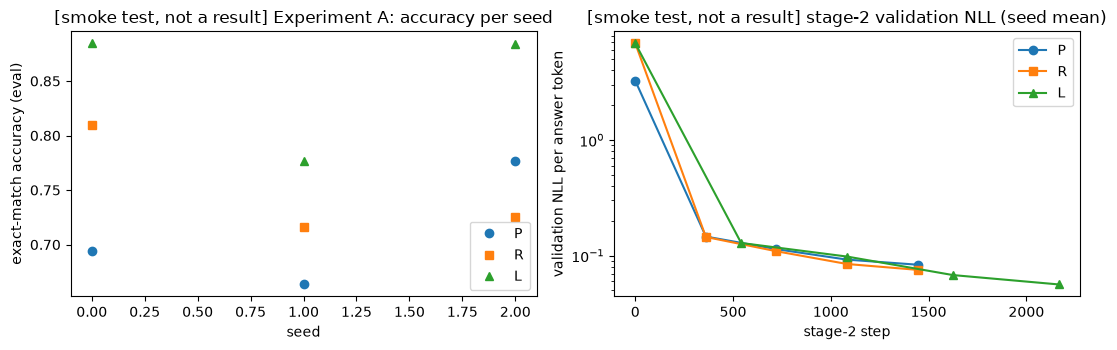

In [13]:
def learning_preconditions(record: dict) -> dict:
    # P1(学習の成立)の各項目(6.1 節): 損失が有限、第 2 段階の検証集合の負の対数尤度が開始時の 0.5 倍以下、第 1 段階は開始時より小さい
    result = {
        "stage2_finite": all(math.isfinite(x) for x in record["stage2_history"]["loss"]),
        "stage2_nll": record["stage2_nll_end"] <= P1_NLL_RATIO * record["stage2_nll_start"],
    }
    if "stage1_history" in record:
        result["stage1_finite"] = all(math.isfinite(x) for x in record["stage1_history"]["loss"])
        result["stage1_nll"] = record["stage1_nll_after"] < record["stage1_nll_before"]  # 下がり幅は問わない(6.2 節の改訂)
    return result


def bootstrap_accuracies(correct_rows: list[np.ndarray], question_type: str | None = None) -> np.ndarray:
    # 画像をクラスタとして復元抽出する対応付きブートストラップ(全行に同じ再標本)。形状 (反復, 行)
    mask = np.ones(len(EVAL_ANSWERS)) if question_type is None else (QUESTION_TYPE_OF_EVAL == question_type).astype(np.float64)
    numerators = np.stack([row.astype(np.float64) * mask for row in correct_rows])
    return paired_cluster_bootstrap_ratio_of_sums(
        numerators, mask, EVAL_IMAGE_OF_QUESTION.tolist(), BOOTSTRAP_RESAMPLES, BOOTSTRAP_SEED
    )


def combined_sigma(per_seed: np.ndarray, bootstrap_contrast: np.ndarray) -> dict:
    seed_variance = float(np.var(per_seed, ddof=1)) / len(per_seed)
    bootstrap_variance = float(np.var(bootstrap_contrast, ddof=1))
    return {
        "sigma": math.sqrt(seed_variance + bootstrap_variance),
        "seed_term": math.sqrt(seed_variance),
        "bootstrap_term": math.sqrt(bootstrap_variance),
    }


_seeds_a = list(range(SEEDS_A))
ACC = {c: np.array([RECORDS[(c, s)]["accuracy"]["all"] for s in range(NUM_SEEDS[c])]) for c in CONDITIONS if NUM_SEEDS[c] > 0}
A_PER_SEED = ACC["P"][:SEEDS_A] - ACC["R"]
_boot = bootstrap_accuracies([RECORDS[("P", s)]["correct"] for s in _seeds_a] + [RECORDS[("R", s)]["correct"] for s in _seeds_a])
_boot_contrast = _boot[:, :SEEDS_A].mean(axis=1) - _boot[:, SEEDS_A:].mean(axis=1)
DELTA_A = float(A_PER_SEED.mean())
SIGMA_A = combined_sigma(A_PER_SEED, _boot_contrast)

# 前提条件(6.1 節)
_p1 = {(c, s): learning_preconditions(RECORDS[(c, s)]) for c in ("P", "R") for s in _seeds_a}
precondition_status["P1(A)"] = all(all(v.values()) for v in _p1.values())
_swapped_a = {c: float(np.mean([RECORDS[(c, s)]["accuracy_swapped"]["all"] for s in _seeds_a])) for c in ("P", "R")}
precondition_status["P2(A)"] = all(v <= P2_SWAPPED_MAX for v in _swapped_a.values())
_base_a = float(ACC["R"].mean())
precondition_status["P3(A)"] = _base_a <= P3_ROOM_MAX
A_PRECONDITIONS = ["P0(A)", "P1(A)", "P2(A)", "P3(A)"]
A_COMPUTED = judge(DELTA_A, SIGMA_A["sigma"])
A_VERDICT = A_COMPUTED if all(precondition_status[k] for k in A_PRECONDITIONS) else "前提不成立"

print(f"{_tag}実験 A(シード {_seeds_a})")
print(f"  正解率 acc_P: {np.round(ACC['P'][:SEEDS_A], 4).tolist()}、acc_R: {np.round(ACC['R'], 4).tolist()}")
print(f"  d_s = acc_P - acc_R: {np.round(A_PER_SEED, 4).tolist()}")
print(
    f"  Delta_A = {DELTA_A:+.4f}、sigma_A = {SIGMA_A['sigma']:.4f}(シード間 {SIGMA_A['seed_term']:.4f}・ブートストラップ "
    f"{SIGMA_A['bootstrap_term']:.4f}、反復 {BOOTSTRAP_RESAMPLES:,})、閾値 2 sigma_A = {SIGMA_MULTIPLIER * SIGMA_A['sigma']:.4f}"
)
print(
    f"  前提条件: P0 {precondition_status['P0(A)']}、P1 {precondition_status['P1(A)']}"
    f"(不成立の学習 {[k for k, v in _p1.items() if not all(v.values())] or 'なし'})、"
    f"P2 {precondition_status['P2(A)']}(画像を差し替えた正解率 {json.dumps({k: round(v, 4) for k, v in _swapped_a.items()})} <= {P2_SWAPPED_MAX})、"
    f"P3 {precondition_status['P3(A)']}(acc_R の平均 {_base_a:.4f} <= {P3_ROOM_MAX})"
)
print(f"  判定関数の結果 {A_COMPUTED} -> {_tag}最終判定: {A_VERDICT}")

# 診断量(判定なし)
_fractions = (0.0, *INTERMEDIATE_EVAL_FRACTIONS, 1.0)


def nll_curve(record: dict) -> list[float]:
    evaluations = record["stage2_history"]["evaluations"]
    middle = [evaluations[s]["validation_nll"] for s in sorted(evaluations)]
    return [record["stage2_nll_start"], *middle, record["stage2_nll_end"]]


print("  診断量: 第 2 段階の検証集合の負の対数尤度(開始時・25%・50%・75%・終わり、シード平均)")
for _c in ("P", "R", "L", "M"):
    if NUM_SEEDS[_c] > 0:
        _curves = np.array([nll_curve(RECORDS[(_c, s)]) for s in range(NUM_SEEDS[_c])])
        print(f"    {_c}: {np.round(_curves.mean(axis=0), 4).tolist()}")
for _c in ("P", "R", "L", "M"):
    if NUM_SEEDS[_c] > 0:
        _recs = [RECORDS[(_c, s)] for s in range(NUM_SEEDS[_c])]
        _norms = {k: float(np.mean([r[k] for r in _recs])) for k in ("norm_init", "norm_after_stage1", "norm_after_stage2") if k in _recs[0]}
        print(
            f"    視覚トークンの平均ノルム {_c}: "
            + "、".join(f"{k} {v:.3f}(埋め込みの {v / TOKEN_EMBEDDING_NORM:.1f} 倍)" for k, v in _norms.items())
        )
if NUM_SEEDS["L"] > 0:
    print(f"    L(総ステップ数を P に揃えた第 2 段階のみ)の正解率: {np.round(ACC['L'], 4).tolist()}、平均 {ACC['L'].mean():.4f}")

_fig, _axes = plt.subplots(1, 2, figsize=(11, 3.6))
for _c, _marker in (("P", "o"), ("R", "s"), ("L", "^")):
    if NUM_SEEDS[_c] > 0:
        _axes[0].plot(range(NUM_SEEDS[_c]), ACC[_c], _marker, label=_c)
        _curves = np.array([nll_curve(RECORDS[(_c, s)]) for s in range(NUM_SEEDS[_c])])
        _x = np.array(_fractions) * CONDITIONS[_c]["stage2_steps"]
        _axes[1].plot(_x, _curves.mean(axis=0), marker=_marker, label=_c)
_axes[0].set_xlabel("seed")
_axes[0].set_ylabel("exact-match accuracy (eval)")
_axes[0].set_title(f"{_plot_tag}Experiment A: accuracy per seed")
_axes[0].legend()
_axes[1].set_xlabel("stage-2 step")
_axes[1].set_ylabel("validation NLL per answer token")
_axes[1].set_yscale("log")
_axes[1].set_title(f"{_plot_tag}stage-2 validation NLL (seed mean)")
_axes[1].legend()
plt.tight_layout()
plt.show()

### 6.8 実験 B: 視覚トークンの取り方 × 質問の種類

[動作確認のみ、結論ではない] 実験 B(シード [0, 1, 2])
  acc^color_P: [0.8175, 0.8106, 0.8563]
  acc^spatial_P: [0.5699, 0.5163, 0.6963]
  acc^color_M: [0.7957, 0.7891, 0.8127]
  acc^spatial_M: [0.5139, 0.5163, 0.536]
  c_s(色の差): [0.0218, 0.0215, 0.0436]、p_s(位置関係の差): [0.0561, 0.0, 0.1603]
  d_s = p_s - c_s: [0.0343, -0.0215, 0.1167]
  Delta_B = +0.0432、sigma_B = 0.0409(シード間 0.0401・ブートストラップ 0.0079、反復 1,000)、閾値 2 sigma_B = 0.0818
  前提条件: P0 True、P1 True(不成立の学習 なし)、P2 True(画像を差し替えた正解率 {"P": 0.1988, "M": 0.2033} <= 0.5)、P3 True(acc^spatial_M の平均 0.5220 <= 0.95)
  判定関数の結果 判定不能 -> [動作確認のみ、結論ではない] 最終判定: 判定不能
  診断量: 色の差の平均 +0.0290、位置関係の差の平均 +0.0721
  診断量: テンプレートごとの正解率(シード平均) P color #0: 0.8227、P color #1: 0.8336、P spatial #0: 0.5896、P spatial #1: 0.5988、M color #0: 0.7918、M color #1: 0.8066、M spatial #0: 0.5249、M spatial #1: 0.5192


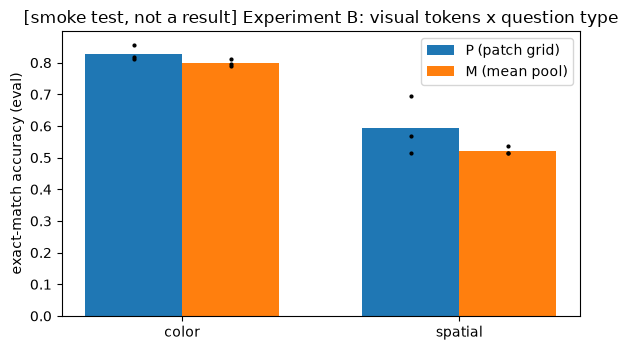

In [14]:
_seeds_b = list(range(SEEDS_B))
ACC_TYPE = {
    (c, t): np.array([RECORDS[(c, s)]["accuracy"][t] for s in _seeds_b]) for c in ("P", "M") for t in QUESTION_TYPES
}
B_COLOR = ACC_TYPE[("P", "color")] - ACC_TYPE[("M", "color")]  # c_s
B_SPATIAL = ACC_TYPE[("P", "spatial")] - ACC_TYPE[("M", "spatial")]  # p_s
B_PER_SEED = B_SPATIAL - B_COLOR  # d_s
_rows = [RECORDS[("P", s)]["correct"] for s in _seeds_b] + [RECORDS[("M", s)]["correct"] for s in _seeds_b]
_boot_type = {t: bootstrap_accuracies(_rows, t) for t in QUESTION_TYPES}  # 同じシードなので再標本は共通
_boot_diff = {t: _boot_type[t][:, :SEEDS_B].mean(axis=1) - _boot_type[t][:, SEEDS_B:].mean(axis=1) for t in QUESTION_TYPES}
_boot_contrast_b = _boot_diff["spatial"] - _boot_diff["color"]
DELTA_B = float(B_PER_SEED.mean())
SIGMA_B = combined_sigma(B_PER_SEED, _boot_contrast_b)

_p1b = {(c, s): learning_preconditions(RECORDS[(c, s)]) for c in ("P", "M") for s in _seeds_b}
precondition_status["P1(B)"] = all(all(v.values()) for v in _p1b.values())
_swapped_b = {c: float(np.mean([RECORDS[(c, s)]["accuracy_swapped"]["all"] for s in _seeds_b])) for c in ("P", "M")}
precondition_status["P2(B)"] = all(v <= P2_SWAPPED_MAX for v in _swapped_b.values())
_base_b = float(ACC_TYPE[("M", "spatial")].mean())
precondition_status["P3(B)"] = _base_b <= P3_ROOM_MAX
B_PRECONDITIONS = ["P0(B)", "P1(B)", "P2(B)", "P3(B)"]
B_COMPUTED = judge(DELTA_B, SIGMA_B["sigma"])
B_VERDICT = B_COMPUTED if all(precondition_status[k] for k in B_PRECONDITIONS) else "前提不成立"

print(f"{_tag}実験 B(シード {_seeds_b})")
for (_c, _t), _v in ACC_TYPE.items():
    print(f"  acc^{_t}_{_c}: {np.round(_v, 4).tolist()}")
print(f"  c_s(色の差): {np.round(B_COLOR, 4).tolist()}、p_s(位置関係の差): {np.round(B_SPATIAL, 4).tolist()}")
print(f"  d_s = p_s - c_s: {np.round(B_PER_SEED, 4).tolist()}")
print(
    f"  Delta_B = {DELTA_B:+.4f}、sigma_B = {SIGMA_B['sigma']:.4f}(シード間 {SIGMA_B['seed_term']:.4f}・ブートストラップ "
    f"{SIGMA_B['bootstrap_term']:.4f}、反復 {BOOTSTRAP_RESAMPLES:,})、閾値 2 sigma_B = {SIGMA_MULTIPLIER * SIGMA_B['sigma']:.4f}"
)
print(
    f"  前提条件: P0 {precondition_status['P0(B)']}、P1 {precondition_status['P1(B)']}"
    f"(不成立の学習 {[k for k, v in _p1b.items() if not all(v.values())] or 'なし'})、"
    f"P2 {precondition_status['P2(B)']}(画像を差し替えた正解率 {json.dumps({k: round(v, 4) for k, v in _swapped_b.items()})} <= {P2_SWAPPED_MAX})、"
    f"P3 {precondition_status['P3(B)']}(acc^spatial_M の平均 {_base_b:.4f} <= {P3_ROOM_MAX})"
)
print(f"  判定関数の結果 {B_COMPUTED} -> {_tag}最終判定: {B_VERDICT}")
# 診断量: 色の差と位置関係の差それぞれのシード平均(交互作用の成分)
print(f"  診断量: 色の差の平均 {B_COLOR.mean():+.4f}、位置関係の差の平均 {B_SPATIAL.mean():+.4f}")
_by_template = {}
for _c in ("P", "M"):
    for _t, _templates in (("color", COLOR_TEMPLATES), ("spatial", SPATIAL_TEMPLATES)):
        for _k in range(len(_templates)):
            _mask = np.array([q.question_type == _t and q.template_index == _k for q in QUESTIONS["eval"]])
            _by_template[(_c, _t, _k)] = float(np.mean([RECORDS[(_c, s)]["correct"][_mask].mean() for s in _seeds_b]))
print("  診断量: テンプレートごとの正解率(シード平均) " + "、".join(f"{k[0]} {k[1]} #{k[2]}: {v:.4f}" for k, v in _by_template.items()))

_fig, _ax = plt.subplots(figsize=(6, 3.6))
_width = 0.35
for _i, _c in enumerate(("P", "M")):
    _means = [ACC_TYPE[(_c, t)].mean() for t in QUESTION_TYPES]
    _ax.bar(np.arange(len(QUESTION_TYPES)) + (_i - 0.5) * _width, _means, _width, label=f"{_c} ({'patch grid' if _c == 'P' else 'mean pool'})")
    for _j, _t in enumerate(QUESTION_TYPES):
        _ax.plot(np.full(SEEDS_B, _j + (_i - 0.5) * _width), ACC_TYPE[(_c, _t)], "k.", markersize=4)
_ax.set_xticks(range(len(QUESTION_TYPES)), QUESTION_TYPES)
_ax.set_ylabel("exact-match accuracy (eval)")
_ax.set_title(f"{_plot_tag}Experiment B: visual tokens x question type")
_ax.legend()
plt.tight_layout()
plt.show()

### 6.9 診断量: 線形プローブ(判定なし)

5.7 節の線形プローブを、2 つの標的 × 2 つの入力で学習・評価する。実験 B の結果の解釈(特に支持以外の結果が出たときの「なぜそうなったか」の
考察)の材料とする。

In [15]:
_t0_probe = time.time()
PROBE_RESULTS = {(t, i): run_probe(t, i) for t in PROBE_TARGETS for i in PROBE_INPUTS}
PROBE_SECONDS = time.time() - _t0_probe
for (_target, _inputs), _r in PROBE_RESULTS.items():
    print(
        f"{_tag}線形プローブ 標的 {_target}・入力 {_inputs}: 評価用の正解率 {_r['eval']:.4f}(学習用 {_r['train']:.4f}、"
        f"最終の訓練損失 {_r['final_loss']:.4f}、チャンス 1/{_r['classes']} = {1 / _r['classes']:.3f}、最頻のクラス {_r['majority']:.3f})"
    )
print(f"線形プローブ: {PROBE_SECONDS:.1f}s(見積もり {ESTIMATE_PROBE:.1f}s)")

[動作確認のみ、結論ではない] 線形プローブ 標的 layout・入力 patch: 評価用の正解率 0.8774(学習用 1.0000、最終の訓練損失 0.0056、チャンス 1/10 = 0.100、最頻のクラス 0.107)
[動作確認のみ、結論ではない] 線形プローブ 標的 layout・入力 mean: 評価用の正解率 0.8012(学習用 0.8031、最終の訓練損失 0.5302、チャンス 1/10 = 0.100、最頻のクラス 0.107)
[動作確認のみ、結論ではない] 線形プローブ 標的 shape_pair・入力 patch: 評価用の正解率 0.6641(学習用 1.0000、最終の訓練損失 0.0371、チャンス 1/10 = 0.100、最頻のクラス 0.119)
[動作確認のみ、結論ではない] 線形プローブ 標的 shape_pair・入力 mean: 評価用の正解率 0.6281(学習用 0.6605、最終の訓練損失 0.9191、チャンス 1/10 = 0.100、最頻のクラス 0.119)
線形プローブ: 9.1s(見積もり 16.4s)


### 6.10 不変条件のアサーションと`SMOKE_TEST`の配線

- 5.2 節で印字した水準(ステップ数・シード数・計画)と、実際の学習の記録が一致すること。
- 同じシードの条件どうしで、projection 層と LoRA の初期値、第 2 段階のミニバッチの順序が一致すること(L は第 2 段階が長いので、
  ミニバッチの添字の列の先頭 $T_2$ ステップが一致することを 5.5 節で確かめた)。第 1 段階を行う P・M の第 1 段階のミニバッチの順序が
  一致すること。
- 学習率が 6.5 節の規則のとおりであること。較正の学習の記録が評価集合の鍵を持たないこと。
- 評価の事例数・質問の種類の事例数が全条件で同じであること。

In [16]:
# --- 実効水準の照合(SMOKE_TEST の配線) ---
assert BOOTSTRAP_RESAMPLES == LEVELS[CURRENT_LEVEL_NAME]["BOOTSTRAP_RESAMPLES"]
assert STAGE_CFG == STAGES[CURRENT_LEVEL_NAME][STAGE] and SELECTED_PLAN in PLANS
for _c in CONDITIONS:
    _seeds = sorted(s for (c, s) in RECORDS if c == _c)
    assert _seeds == list(range(NUM_SEEDS[_c])), (_c, _seeds)
    assert NUM_SEEDS[_c] == seeds_for(_c, STAGES[CURRENT_LEVEL_NAME][STAGE])
for (_c, _s), _r in RECORDS.items():
    _spec = CONDITIONS[_c]
    assert _r["stage2_history"]["steps"] == _spec["stage2_steps"] == len(_r["stage2_history"]["loss"])
    assert ("stage1_history" in _r) == _spec["stage1"]
    if _spec["stage1"]:
        assert _r["stage1_history"]["steps"] == STAGE1_STEPS == len(_r["stage1_history"]["loss"])
        assert all(n.startswith("projection.") for n in _r["stage1_history"]["trainable_names"])  # 第 1 段階は projection 層のみ
    _names2 = _r["stage2_history"]["trainable_names"]  # 第 2 段階は projection 層と LoRA のみ
    assert all(n.startswith("projection.") or ".lora_" in n for n in _names2)
    assert sum(".lora_" in n for n in _names2) == 2 * len(LORA_TARGET_MODULES) * NUM_LAYERS
    assert (_r["lr1"], _r["lr2"]) == LEARNING_RATES[_c]
    assert len(_r["correct"]) == len(_r["correct_swapped"]) == len(EVAL_ANSWERS)
# --- 対応のある比較: 同じシードの条件どうしで初期値・ミニバッチの順序が一致する ---
for _s in range(max(NUM_SEEDS.values())):
    _present = [c for c in CONDITIONS if (c, _s) in RECORDS]
    assert len({RECORDS[(c, _s)]["initial_trainable_sha256"] for c in _present}) == 1
    assert len({RECORDS[(c, _s)]["lora_init_sha256"] for c in _present}) == 1
    _same_length = [c for c in _present if CONDITIONS[c]["stage2_steps"] == STAGE2_STEPS]
    assert len({RECORDS[(c, _s)]["stage2_history"]["batch_sha256"] for c in _same_length}) == 1
    _with_stage1 = [c for c in _present if CONDITIONS[c]["stage1"]]
    assert len({RECORDS[(c, _s)]["stage1_history"]["batch_sha256"] for c in _with_stage1}) <= 1
# 異なるシードどうしでは初期値が異なる(確認の検出力)
if NUM_SEEDS["P"] >= 2:
    assert RECORDS[("P", 0)]["initial_trainable_sha256"] != RECORDS[("P", 1)]["initial_trainable_sha256"]
# --- 較正 ---
assert set(CALIBRATION) == set(calibration_targets(CALIBRATION_MODE))
for _key, _c in CALIBRATION.items():
    assert _c["chosen"] in _c["nll"] and len(_c["nll"]) in (3, 4)
# --- 評価集合の事例数は全条件で同じ ---
assert len(EVAL_ANSWERS) == 4 * NUM_IMAGES["eval"]
assert all(int((QUESTION_TYPE_OF_EVAL == t).sum()) == 2 * NUM_IMAGES["eval"] for t in QUESTION_TYPES)
print(
    f"実効水準の照合: 計画 {SELECTED_PLAN['plan']}・段階 {STAGE}・較正 {CALIBRATION_MODE!r}・シード数 {NUM_SEEDS}・"
    f"T_1 = {STAGE1_STEPS}・T_2 = {STAGE2_STEPS}・ブートストラップ {BOOTSTRAP_RESAMPLES:,} 回が、実際の学習の記録と一致: OK"
)
print("同じシードの条件どうしで projection 層・LoRA の初期値とミニバッチの順序が一致、学習率は 6.5 節の規則どおり、較正は評価集合を評価していない: OK")

実効水準の照合: 計画 0・段階 0・較正 'all'・シード数 {'P': 3, 'R': 3, 'L': 3, 'M': 3}・T_1 = 722・T_2 = 1444・ブートストラップ 1,000 回が、実際の学習の記録と一致: OK
同じシードの条件どうしで projection 層・LoRA の初期値とミニバッチの順序が一致、学習率は 6.5 節の規則どおり、較正は評価集合を評価していない: OK


### 6.11 判定結果の一覧

In [17]:
print(f"{_tag}判定結果(計画 {SELECTED_PLAN['plan']}、段階 {STAGE}、較正の方式 {CALIBRATION_MODE!r})")
for _name, _delta, _sigma, _computed, _verdict, _preconditions in (
    ("実験 A(第 1 段階の効果)", DELTA_A, SIGMA_A["sigma"], A_COMPUTED, A_VERDICT, A_PRECONDITIONS),
    ("実験 B(視覚トークンの取り方 x 質問の種類)", DELTA_B, SIGMA_B["sigma"], B_COMPUTED, B_VERDICT, B_PRECONDITIONS),
):
    print(
        f"  {_name}: 対比量 {_delta:+.4f}、標準偏差 {_sigma:.4f}、閾値 {SIGMA_MULTIPLIER * _sigma:.4f}、"
        f"前提条件 {json.dumps({k: precondition_status[k] for k in _preconditions}, ensure_ascii=False)}、"
        f"判定関数の結果 {_computed} -> 最終判定 {_verdict}"
    )
print(f"\nノートブック全体の実行時間: {(time.time() - NOTEBOOK_START_TIME) / 60:.1f} 分")

[動作確認のみ、結論ではない] 判定結果(計画 0、段階 0、較正の方式 'all')
  実験 A(第 1 段階の効果): 対比量 -0.0391、標準偏差 0.0490、閾値 0.0980、前提条件 {"P0(A)": true, "P1(A)": true, "P2(A)": true, "P3(A)": true}、判定関数の結果 判定不能 -> 最終判定 判定不能
  実験 B(視覚トークンの取り方 x 質問の種類): 対比量 +0.0432、標準偏差 0.0409、閾値 0.0818、前提条件 {"P0(B)": true, "P1(B)": true, "P2(B)": true, "P3(B)": true}、判定関数の結果 判定不能 -> 最終判定 判定不能

ノートブック全体の実行時間: 61.4 分


## 7. 結果・考察 / Results and Discussion

**(本番実行の後に記述する。第 1 段階の時点では、節の見出しと何を書くかのみを置く。スモークテストの数値に基づく考察は書かない。)**

判定(7.3・7.4 節)は 6.1 節で事前に宣言した基準のみから導く。結果を見た後に立てた解釈は 7.6 節に分けて記し、検証済みの結論としては
扱わない。

### 7.1 実行の概要

- 実行環境(5.1 節の印字: GPU・compute capability・メモリ、Python・torch・CUDA・cuDNN、コミット、未コミットの変更の有無、実行日時)。
- データの準備・確認・スケーリングの計測にかかった時間と、計画の選択の時点の経過時間。
- T4 の定常状態の 1 ステップの時間(6.3 節、4 種類)と、べき指数・比例の値との差。バッチ 16 と 32 の比(固定費が支配的か)。
- 選ばれた計画(段階・較正の方式)と、その見積もり。実際の実行時間(較正・本番の学習と評価・全体)と、見積もりとの差。
- 学習率の較正の表(格子点と検証集合の負の対数尤度、拡張の有無、選んだ学習率)。

### 7.2 前提条件

- P0〜P3 の値と成否の表(実験ごと)。画像を見ない戦略の上界(5.4 節)と、画像を差し替えた正解率の比較。

### 7.3 実験 A: 第 1 段階(特徴の整列)の効果

- P・R の正解率の表(シードごと)と、$d_s$・$\Delta_A$・$\sigma_A$(シード間とブートストラップの内訳)・閾値・最終判定。
- 診断量: 第 2 段階の開始時と途中の検証集合の負の対数尤度(作用点に近い量)、視覚トークンのノルム(第 1 段階の前後)、
  L の正解率(段階 0 のみ。総ステップ数を揃えた比較)。

### 7.4 実験 B: 視覚トークンの取り方 × 質問の種類

- P・M の質問の種類ごとの正解率の表と、$c_s$・$p_s$・$d_s$・$\Delta_B$・$\sigma_B$・閾値・最終判定。
- 診断量: 色の差と位置関係の差それぞれの平均、テンプレートごとの正解率、線形プローブの表(7.5 節)。

### 7.5 診断量: 線形プローブ

- 配置・形の組 × 格子全体・平均プールの正解率の表と、チャンス・最頻のクラスとの比較。実験 B の結果との対応(判定なし)。

### 7.6 事後的な解釈(検証済みの結論ではない)

- 支持以外(反証・判定不能・前提不成立)になった実験について、(1)原因の候補(設計と現象の両面)、(2)根拠(セル出力の診断量)、
  (3)確かめる方法、(4)教訓を書く。前提不成立の場合は「なぜ前提が崩れたか」と「判定関数の参考値がなぜその向きになったか」を分けて書く。
- `"representative"`の計画が選ばれた場合は、規則で決めた学習率による偏り(6.1 節)が結論に与えうる影響。
- 原論文との規模・構成の違い(言語モデルの大きさ、LoRA と全パラメータの更新、合成データ)が結論の一般化に与える制約。

### 本番実行の後に更新が必要な箇所

- 1.2 節: 選ばれた計画と、実験 A・B の最終判定の要約を書く。
- 6.2 節: 本番で選ばれた計画とパイロットの設定の関係を確認する。
- 7 節のすべて(上の箇条書きを本文に置き換える)。
- `theories/README.md`の 021 行: 最終判定の要約を追記する。